# **A. VIETNAMESE LAS SPEECH-TO-TEXT**

This notebook builds a sample Vietnamese speech-to-text pipeline using the **LAS architecture**:

```
Audio path -> waveform -> log-mel spectrum -> Listener -> Attention -> Speller -> Vietnamese text
```

The code style follows the uploaded notebook style:
- short explanation cells before code cells
- imports appear near the block that needs them
- constants are introduced only when the block needs them
- `Listener`, `Attention`, and `Speller` are separated for easier examination


```
TEFPA = Task + Experience + Function + Performance + Algorithm
```

**Task**
- **Input:** Audio file path, usually `.wav`.
- **Model input after conversion:** log-mel spectrum with shape `[time_steps, n_mels]`.
- **Output:** Vietnamese text transcription.

**Experience**
- Dataset should be a CSV file with at least 2 columns:
    - `path`: audio file path
    - `text`: transcription

**Function**
- `Listener`: encodes acoustic frames.
- `Attention`: chooses which encoder frames matter at each decoding step.
- `Speller`: predicts Vietnamese characters one by one.

**Performance**
- Training objective: `CrossEntropyLoss`, because it is differentiable.
- Evaluation metric: `Levenshtein Distance` / `CER`.

**Algorithm**
- Listen, Attend and Spell / LAS.


## 0. Config and Tools

Run this cell first if your environment does not have `torchaudio`.

In Kaggle/Colab, `torch` is usually already available. If install fails, restart the runtime after installation.


In [ ]:
import torchaudio
import os
os.listdir("/kaggle/input/datasets/kaleykim297/vn-audio2")
os.chdir("/kaggle/input/datasets/kaleykim297/vn-audio2")

In [123]:
os.listdir("/kaggle/input/datasets/kaleykim297/vivos-audio2/vivos/test")

['waves', 'genders.txt', 'prompts.txt']

In [124]:
import os
import pandas as pd
import numpy as np
import random
import json
import math
from pathlib import Path
import shutil

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Sampler
from torch.nn.utils.rnn import pad_sequence

import sklearn
from sklearn.model_selection import train_test_split

import librosa
import librosa.display
import soundfile as sf

ROOT_DIR = "./cv-corpus-25.0-2026-03-09/vi"
invalidated_path = os.path.join(ROOT_DIR, "invalidated.tsv")

OUTPUT_DIR = "/kaggle/working"
BEST_CHECKPOINT_PATH = os.path.join(OUTPUT_DIR, "best_checkpoint.pt")
LAST_CHECKPOINT_PATH = os.path.join(OUTPUT_DIR, "last_checkpoint.pt")
TOKENIZER_PATH = os.path.join(OUTPUT_DIR, "v2tokenizer.json")

best_valid_cer = float("inf")
best_epoch = -1

RANDOM_STATE = 42

### a. Save checkpoint

In [125]:
def save_checkpoint(
    path, model, optimizer, epoch,
    valid_cer, valid_loss, train_metrics, tokenizer, valid_ser=None,
    best_valid_cer=None, best_epoch=None, best_valid_ser=None, best_ser_epoch=None,
    teacher_forcing_rate=None
):
    checkpoint_payload = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "epoch": epoch,
        "valid_cer": valid_cer,
        "valid_loss": valid_loss,
        "valid_ser": valid_ser,
        "train_metrics": train_metrics,

        "best_valid_cer": best_valid_cer,
        "best_epoch": best_epoch,
        "best_valid_ser": best_valid_ser,
        "best_ser_epoch": best_ser_epoch,
        "teacher_forcing_rate": teacher_forcing_rate,

        "input_dim": INPUT_DIM,
        "vocab_size": len(tokenizer),
        "listener_hidden_dim": LISTENER_HIDDEN_DIM,
        "decoder_dim": DECODER_DIM,
        "embedding_dim": EMBEDDING_DIM,
        "attention_dim": ATTENTION_DIM,

        "conformer_layers": CONFORMER_LAYERS,
        "conformer_heads": CONFORMER_HEADS,
        "conformer_ff_expansion": CONFORMER_FF_EXPANSION,
        "conformer_conv_kernel": CONFORMER_CONV_KERNEL,
        "dropout": DROPOUT,

        "sample_rate": SAMPLE_RATE,
        "n_mels": N_MELS,
        "n_fft": N_FFT,
        "hop_length": HOP_LENGTH,

        "tokenizer_type": getattr(tokenizer, "tokenizer_type", type(tokenizer).__name__),
        "ctc_weight": globals().get("CTC_WEIGHT", None),
        "has_ctc_head": True,
    }

    torch.save(checkpoint_payload, path)

### b. Save tokenizer

In [126]:
def save_tokenizer(path, tokenizer):
    tokenizer_payload = {
        "tokenizer_type": getattr(tokenizer, "tokenizer_type", type(tokenizer).__name__),
        "pad_id": tokenizer.pad_id,
        "sos_id": tokenizer.sos_id,
        "eos_id": tokenizer.eos_id,
        "unk_id": tokenizer.unk_id,
    }

    if hasattr(tokenizer, "stoi"):
        tokenizer_payload["stoi"] = tokenizer.stoi
        tokenizer_payload["itos"] = tokenizer.itos

    if hasattr(tokenizer, "min_freq"):
        tokenizer_payload["min_freq"] = tokenizer.min_freq

    if getattr(tokenizer, "tokenizer_type", "") == "sentencepiece_bpe":
        tokenizer_payload["sentencepiece_model"] = tokenizer.model_path

    with open(path, "w", encoding="utf-8") as f:
        json.dump(tokenizer_payload, f, ensure_ascii=False, indent=2)

### c. Filtering duration

In [127]:
import soundfile as sf
def audio_duration_ms(audio_path):
    audio_path = str(audio_path)

    # Fast path for wav/flac and many supported audio files.
    if sf is not None:
        try:
            info = sf.info(audio_path)
            return 1000.0 * info.frames / info.samplerate
        except Exception:
            pass

    # Fallback: slower but robust if librosa can decode the file.
    y, sr = librosa.load(audio_path, sr=None, mono=True)
    return 1000.0 * len(y) / sr

In [128]:
def fill_missing_duration_ms(df):
    df = df.copy()

    missing_mask = df["duration_ms"].isna()

    if missing_mask.sum() > 0:
        print("Filling missing duration_ms:", missing_mask.sum())

        df.loc[missing_mask, "duration_ms"] = df.loc[
            missing_mask, "audio_path"
        ].apply(audio_duration_ms)

    return df

### d. Conditions for inspection, resuming, type of embedding

In [129]:
INSPECT_CHECKPOINT = False
RESUME_TRAINING = True
TOKENIZER_TYPE = "bpe" # "character", "syllable", "bpe"

LEARNING_RATE = 3e-4
EPOCHS = 300
CTC_WEIGHT = 0.3
EARLY_STOPPING = 50
epochs_without_best = 0

RESUME_FINETUNE = False

DROPOUT = 0.2
CONFORMER_LAYERS = 4
CONFORMER_HEADS = 4
CONFORMER_CONV_KERNEL = 15

SPEED_CHOICES = (0.9, 1.0, 1.1)
TRAIN_NOISE_OK = True
TRAIN_PITCH_OK = True
PITCH_STEPS_RANGE = (-1.5, 1.5)

RUN_BPE_EXPERIMENT = False
USE_SSL_PRETRAINED_ENCODER = False
RUN_SSL_PRETRAINING = False

RUN_ASR = True
VIVOS_ROOT = Path("/kaggle/input/datasets/kaleykim297/vivos-audio2/vivos")
SSL_CHECKPOINT_PATH = Path("/kaggle/working/ssl_conformer_encoder.pt")

### e. Copying past models to working for resuming

In [130]:
if RESUME_TRAINING or RESUME_FINETUNE:
    paths = {
        "LAST_CHECKPT" : Path("/kaggle/input/models/kaleykim297/l-checkpt2/pytorch/default/1/last_checkpoint.pt"),
        "BEST_CHECKPT" : Path("/kaggle/input/models/kaleykim297/best-checkpt2/pytorch/default/1/best_checkpoint.pt"),
        "MODEL" : Path("/kaggle/input/models/kaleykim297/model2/pytorch/default/1/vi_bpe.model"),
        "SER_CHECKPT" : Path("/kaggle/input/models/kaleykim297/ser-checkpt2/pytorch/default/1/best_ser_checkpoint.pt"),
        "VOCAB" : Path("/kaggle/input/models/kaleykim297/vocab2/pytorch/default/1/vi_bpe.vocab"),
        "TOKENIZER" : Path("/kaggle/input/datasets/kaleykim297/tokenizer2/v2tokenizer.json"),
    }
    OUTPUT_DIR = Path("/kaggle/working")
    mapping = {
        "LAST_CHECKPT" : "last_checkpoint.pt",
        "BEST_CHECKPT" : "best_checkpoint.pt",
        "MODEL" : "vi_bpe.model",
        "SER_CHECKPT" : "best_ser_checkpoint.pt",
        "VOCAB" : "vi_bpe.vocab",
        "TOKENIZER" : "v2tokenizer.json",
    }
    for name in mapping.keys():
        src = paths[name]
        dst = OUTPUT_DIR / mapping[name]
        if src.exists():
            shutil.copy2(src, dst)
            print("Copied:", name)
        else:
            print("Missing, skipped:", name)

Copied: LAST_CHECKPT
Copied: BEST_CHECKPT
Copied: MODEL
Copied: SER_CHECKPT
Copied: VOCAB
Copied: TOKENIZER


## 1. Dataset

Expected corpus format:

| path | text |
|---|---|
| /content/audio_001.wav | xin chào bạn |
| /content/audio_002.wav | tôi đang học mô hình speech to text |

For now, the notebook creates a tiny fake dataset if your real CSV is not found.  
Replace `CSV_PATH` and `AUDIO_ROOT` with your real Vietnamese corpus paths.


### a. Common Voice

In [131]:
ROOT_DIR = "./cv-corpus-25.0-2026-03-09/vi"

required_files = ["train.tsv", "dev.tsv", "test.tsv", "validated.tsv", "clip_durations.tsv"]
for filename in required_files:
    full_path = os.path.join(ROOT_DIR, filename)
    if not os.path.exists(full_path):
        raise FileNotFoundError(
            f"Missing {full_path}. Check ROOT_DIR. Current ROOT_DIR={ROOT_DIR}"
        )

duration_df = pd.read_csv(
    os.path.join(ROOT_DIR, "clip_durations.tsv"),
    sep="\t"
)

duration_df = duration_df.rename(columns={
    "clip": "path",
    "duration[ms]": "duration_ms"
})

train_df = pd.read_csv(os.path.join(ROOT_DIR, "train.tsv"), sep="\t")
valid_df = pd.read_csv(os.path.join(ROOT_DIR, "validated.tsv"), sep="\t")
test_df = pd.read_csv(os.path.join(ROOT_DIR, "test.tsv"), sep="\t")
dev_df = pd.read_csv(os.path.join(ROOT_DIR, "dev.tsv"), sep="\t")

for split_name, split_df in [("train", train_df), ("valid", valid_df), ("test", test_df), ("dev", dev_df)]:
    required_cols = {"path", "sentence"}
    missing_cols = required_cols - set(split_df.columns)
    if missing_cols:
        raise ValueError(f"{split_name}.tsv is missing columns: {missing_cols}")

for df in [train_df, valid_df, test_df, dev_df]:
    df["audio_path"] = df["path"].apply(lambda x: os.path.join(ROOT_DIR, "clips", x))

# Keep shorter clips for the first LAS baseline. Long clips make attention harder.
MIN_DURATION_MS = 500
MAX_DURATION_MS = 15000

train_df = train_df.merge(duration_df, on="path", how="left")
valid_df = valid_df.merge(duration_df, on="path", how="left")
test_df = test_df.merge(duration_df, on="path", how="left")
dev_df = dev_df.merge(duration_df, on="path", how="left")

train_df = fill_missing_duration_ms(train_df)
valid_df = fill_missing_duration_ms(valid_df)
test_df = fill_missing_duration_ms(test_df)
dev_df = fill_missing_duration_ms(dev_df)

train_df = train_df[
    (train_df["duration_ms"] >= MIN_DURATION_MS) &
    (train_df["duration_ms"] <= MAX_DURATION_MS)
].reset_index(drop=True)
train_df = train_df.rename(columns={"sentence": "text"})

valid_df = valid_df[
    (valid_df["duration_ms"] >= MIN_DURATION_MS) &
    (valid_df["duration_ms"] <= MAX_DURATION_MS)
].reset_index(drop=True)
valid_df = valid_df.rename(columns={"sentence": "text"})

test_df = test_df[
    (test_df["duration_ms"] >= MIN_DURATION_MS) &
    (test_df["duration_ms"] <= MAX_DURATION_MS)
].reset_index(drop=True)
test_df = test_df.rename(columns={"sentence": "text"})

dev_df = dev_df[
    (dev_df["duration_ms"] >= MIN_DURATION_MS) &
    (dev_df["duration_ms"] <= MAX_DURATION_MS)
].reset_index(drop=True)
dev_df = dev_df.rename(columns={"sentence": "text"})

# Check a few actual audio files.
missing_audio = train_df[~train_df["audio_path"].apply(os.path.exists)].head(5)
if len(missing_audio) > 0:
    raise FileNotFoundError(
        "Some audio files are missing. First examples:\n" +
        "\n".join(missing_audio["audio_path"].tolist())
    )

print("Train:", len(train_df), "Valid:", len(valid_df), "Test:", len(test_df), "Dev:", len(dev_df))
train_df[["audio_path", "text", "duration_ms"]].head()

Filling missing duration_ms: 771
Train: 2674 Valid: 4730 Test: 960 Dev: 1333


,audio_path,text,duration_ms
0,./cv-corpus-25.0-2026-03-09/vi/clips/common_vo...,Khi con có mẹ,3936.0
1,./cv-corpus-25.0-2026-03-09/vi/clips/common_vo...,nghe Mẹ Thảo nói bố thảo đi làm trưa mới về,7104.0
2,./cv-corpus-25.0-2026-03-09/vi/clips/common_vo...,Hà ni đánh bạo gọi khẽ,4536.0
3,./cv-corpus-25.0-2026-03-09/vi/clips/common_vo...,Nước chảy trên sông,3816.0
4,./cv-corpus-25.0-2026-03-09/vi/clips/common_vo...,Nào các bạn ơi,3576.0


### b. VIVOS

In [132]:
import soundfile as sf

def read_vivos_prompts(split_dir):
    """
    Read prompts.txt if available.
    VIVOS prompt format is usually:
        utterance_id transcript...
    """
    prompt_path = split_dir / "prompts.txt"
    prompt_map = {}

    if not prompt_path.exists():
        return prompt_map

    with open(prompt_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            parts = line.split(maxsplit=1)
            if len(parts) == 1:
                utt_id = parts[0]
                transcript = ""
            else:
                utt_id, transcript = parts

            prompt_map[utt_id] = transcript

    return prompt_map



def read_vivos_genders(split_dir):
    """
    Read genders.txt if available.
    Format is usually:
        speaker_id gender
    """
    gender_path = split_dir / "genders.txt"
    gender_map = {}

    if not gender_path.exists():
        return gender_map

    with open(gender_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            parts = line.split()
            if len(parts) >= 2:
                speaker_id = parts[0]
                gender = parts[1]
                gender_map[speaker_id] = gender

    return gender_map


def get_audio_duration_sec(path):
    try:
        info = sf.info(str(path))
        return info.frames / info.samplerate
    except Exception:
        return None


def build_vivos_manifest(vivos_root):
    rows = []

    for split in ["train", "test"]:
        split_dir = vivos_root / split
        waves_dir = split_dir / "waves"

        if not waves_dir.exists():
            print("Missing waves dir:", waves_dir)
            continue

        prompt_map = read_vivos_prompts(split_dir)
        gender_map = read_vivos_genders(split_dir)

        wav_paths = sorted(waves_dir.rglob("*.wav"))

        print(f"{split}: found {len(wav_paths)} wav files")

        for wav_path in wav_paths:
            speaker_id = wav_path.parent.name
            utt_id = wav_path.stem

            rows.append({
                "audio_path": str(wav_path),
                "dataset": "vivos",
                "split": split,
                "speaker_id": speaker_id,
                "utterance_id": utt_id,
                "gender": gender_map.get(speaker_id),
                # Optional transcript. Ignore this for SSL pretraining.
                "text": prompt_map.get(utt_id),
                "duration_sec": get_audio_duration_sec(wav_path),
            })

    df = pd.DataFrame(rows)

    df = df.drop_duplicates("audio_path").reset_index(drop=True)

    return df

def build_vivos_df(vivos_root, split="train"):
    vivos_root = Path(vivos_root)
    split_dir = vivos_root / split
    waves_dir = split_dir / "waves"

    if not waves_dir.exists():
        raise FileNotFoundError(f"Missing waves folder: {waves_dir}")

    prompt_map = read_vivos_prompts(split_dir)

    rows = []
    missing_label_count = 0

    for wav_path in sorted(waves_dir.rglob("*.wav")):
        utt_id = wav_path.stem
        speaker_id = wav_path.parent.name

        if utt_id not in prompt_map:
            missing_label_count += 1
            continue

        sentence = prompt_map[utt_id]

        rows.append({
            "audio_path": str(wav_path),
            "path": str(wav_path),
            "sentence": sentence,
            "text": sentence,
            "client_id": f"vivos_{speaker_id}",
            "source": "vivos",
            "split": split,
            "duration_ms": audio_duration_ms(wav_path),
        })

    df = pd.DataFrame(rows)

    print(f"VIVOS {split}: {len(df)} rows")
    print(f"Missing labels: {missing_label_count}")

    return df

if RUN_SSL_PRETRAINING:
    vivos_df = build_vivos_manifest(VIVOS_ROOT)
    
    print("Total VIVOS rows:", len(vivos_df))
    display(vivos_df.head())
    print(vivos_df["split"].value_counts())
    print("Speakers:", vivos_df["speaker_id"].nunique())
    print(vivos_df["duration_sec"].describe())

if RUN_ASR:
    VIVOS_ROOT = Path("/kaggle/input/datasets/kaleykim297/vivos-audio2/vivos")

    vivos_train_df = build_vivos_df(VIVOS_ROOT, split="train")
    vivos_test_df = build_vivos_df(VIVOS_ROOT, split="test")

VIVOS train: 10929 rows
Missing labels: 0
VIVOS test: 720 rows
Missing labels: 0


In [133]:
if RUN_SSL_PRETRAINING:
    vivos_df = vivos_df[
        vivos_df["duration_sec"].notna() &
        (vivos_df["duration_sec"] >= 0.5) &
        (vivos_df["duration_sec"] <= 18.0)
    ].reset_index(drop=True)
    
    print("Filtered VIVOS rows:", len(vivos_df))
    print("Total hours:", vivos_df["duration_sec"].sum() / 3600)
    display(vivos_df.head())

## 2. Text preprocessing

For this LAS sample, the decoder predicts **characters**, not words.

Character-level decoding is easier for Vietnamese because:
- we can keep Vietnamese accents directly
- no word segmentation is required
- unknown words are less painful

### a. CommonVoice

In [134]:
import re
import unicodedata

def normalize_vietnamese_text(text):
    text = str(text).lower().strip()
    text = unicodedata.normalize("NFC", text)

    # Keep letters, digits, Vietnamese accents, and spaces.
    # Remove most punctuation for the first baseline.
    text = re.sub(r"[^0-9a-zA-ZÀ-ỹ\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

for df in [train_df, valid_df, test_df, dev_df]:
    df["text_norm"] = df["text"].apply(normalize_vietnamese_text)
    df["char_len"] = df["text_norm"].apply(len)
    df["word_len"] = df["text_norm"].apply(lambda x: len(x.split()))

display(train_df[["text", "text_norm"]].head())

,text,text_norm
0,Khi con có mẹ,khi con có mẹ
1,nghe Mẹ Thảo nói bố thảo đi làm trưa mới về,nghe mẹ thảo nói bố thảo đi làm trưa mới về
2,Hà ni đánh bạo gọi khẽ,hà ni đánh bạo gọi khẽ
3,Nước chảy trên sông,nước chảy trên sông
4,Nào các bạn ơi,nào các bạn ơi


In [135]:
from collections import Counter
all_text = " ".join(train_df["text_norm"])
char_counter = Counter(all_text)
cnt = 0
for ch, count in sorted(char_counter.items(), key=lambda x: x[1]):
    cnt += 1
    print(repr(ch), count)
    if cnt == 10:
        break

'ỵ' 2
'f' 3
'ẵ' 5
'ỹ' 15
'ỷ' 19
'ỳ' 25
'ỡ' 28
'õ' 29
'ễ' 35
'ẩ' 42


In [136]:
MAX_CHAR_LEN = 160
MAX_WORD_LEN = 35

for df_name in ["train_df", "valid_df", "test_df", "dev_df"]:
    temp_df = globals()[df_name]

    temp_df = temp_df[
        (temp_df["text_norm"].str.len() > 0) &
        (temp_df["char_len"] <= MAX_CHAR_LEN) &
        (temp_df["word_len"] <= MAX_WORD_LEN)
    ].reset_index(drop=True)

    globals()[df_name] = temp_df

### b. VIVOS

In [137]:
if RUN_ASR:
    vivos_train_df["text_norm"] = vivos_train_df["sentence"].apply(normalize_vietnamese_text)
    vivos_test_df["text_norm"] = vivos_test_df["sentence"].apply(normalize_vietnamese_text)
    
    vivos_train_df["char_len"] = vivos_train_df["text_norm"].apply(len)
    vivos_test_df["char_len"] = vivos_test_df["text_norm"].apply(len)
    
    vivos_train_df["duration_sec"] = vivos_train_df["duration_ms"] / 1000.0
    vivos_test_df["duration_sec"] = vivos_test_df["duration_ms"] / 1000.0
    
    vivos_train_df["word_len"] = vivos_train_df["text_norm"].apply(lambda x: len(x.split()))
    vivos_test_df["word_len"] = vivos_test_df["text_norm"].apply(lambda x: len(x.split()))

    vivos_train_df["chars_per_sec"] = vivos_train_df["duration_sec"] / vivos_train_df["char_len"]
    vivos_test_df["chars_per_sec"] = vivos_test_df["duration_sec"] / vivos_test_df["char_len"]

    vivos_train_df["words_per_sec"] = vivos_train_df["duration_sec"] / vivos_train_df["word_len"]
    vivos_test_df["words_per_sec"] = vivos_test_df["duration_sec"] / vivos_test_df["word_len"]
    
    vivos_train_df = vivos_train_df[
        vivos_train_df["text_norm"].str.len().gt(0) &
        vivos_train_df["duration_sec"].between(0.5, 18.0)
    ].reset_index(drop=True)
    
    vivos_test_df = vivos_test_df[
        vivos_test_df["text_norm"].str.len().gt(0) &
        vivos_test_df["duration_sec"].between(0.5, 18.0)
    ].reset_index(drop=True)
    
    print("VIVOS train rows:", len(vivos_train_df))
    print("VIVOS train hours:", vivos_train_df["duration_sec"].sum() / 3600)
    display(vivos_train_df.head())

VIVOS train rows: 10929
VIVOS train hours: 14.04346532986111


,audio_path,path,sentence,text,client_id,source,split,duration_ms,text_norm,char_len,duration_sec,word_len,chars_per_sec,words_per_sec
0,/kaggle/input/datasets/kaleykim297/vivos-audio...,/kaggle/input/datasets/kaleykim297/vivos-audio...,KHÁCH SẠN,KHÁCH SẠN,vivos_VIVOSSPK01,vivos,train,3000.00,khách sạn,9,3.00000,2,0.333333,1.500000
1,/kaggle/input/datasets/kaleykim297/vivos-audio...,/kaggle/input/datasets/kaleykim297/vivos-audio...,CHỈ BẰNG CÁCH LUÔN NỖ LỰC THÌ CUỐI CÙNG BẠN MỚ...,CHỈ BẰNG CÁCH LUÔN NỖ LỰC THÌ CUỐI CÙNG BẠN MỚ...,vivos_VIVOSSPK01,vivos,train,4937.50,chỉ bằng cách luôn nỗ lực thì cuối cùng bạn mớ...,60,4.93750,14,0.082292,0.352679
2,/kaggle/input/datasets/kaleykim297/vivos-audio...,/kaggle/input/datasets/kaleykim297/vivos-audio...,TRONG SỐ CÁC QUỐC GIA CÔNG NGHIỆP PHÁT TRIỂN,TRONG SỐ CÁC QUỐC GIA CÔNG NGHIỆP PHÁT TRIỂN,vivos_VIVOSSPK01,vivos,train,4343.75,trong số các quốc gia công nghiệp phát triển,44,4.34375,9,0.098722,0.482639
3,/kaggle/input/datasets/kaleykim297/vivos-audio...,/kaggle/input/datasets/kaleykim297/vivos-audio...,ANH ĐÃ NHÌN THẤY TRONG NHỮNG LẢI NHẢI DÔNG DÀI...,ANH ĐÃ NHÌN THẤY TRONG NHỮNG LẢI NHẢI DÔNG DÀI...,vivos_VIVOSSPK01,vivos,train,4968.75,anh đã nhìn thấy trong những lải nhải dông dài...,54,4.96875,12,0.092014,0.414062
4,/kaggle/input/datasets/kaleykim297/vivos-audio...,/kaggle/input/datasets/kaleykim297/vivos-audio...,KHỦNG HOẢNG MÔI TRƯỜNG CẦN ĐƯỢC NGĂN CHẶN,KHỦNG HOẢNG MÔI TRƯỜNG CẦN ĐƯỢC NGĂN CHẶN,vivos_VIVOSSPK01,vivos,train,3250.00,khủng hoảng môi trường cần được ngăn chặn,41,3.25000,8,0.079268,0.406250


## 3. EDA for audio and text

- transcript length in characters
- audio file existence
- rough audio duration

### a. Duration

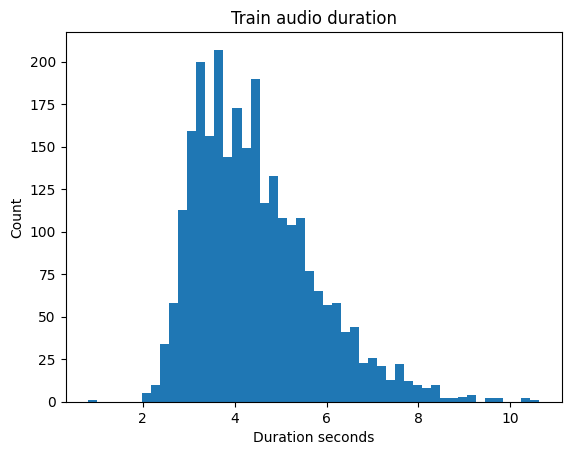

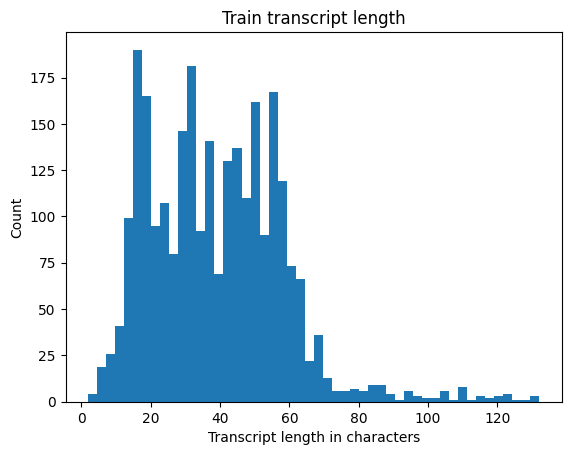

In [138]:
import matplotlib.pyplot as plt

plt.hist(train_df["duration_ms"].dropna() / 1000, bins=50)
plt.xlabel("Duration seconds")
plt.ylabel("Count")
plt.title("Train audio duration")
plt.show()

plt.hist(train_df["char_len"], bins=50)
plt.xlabel("Transcript length in characters")
plt.ylabel("Count")
plt.title("Train transcript length")
plt.show()

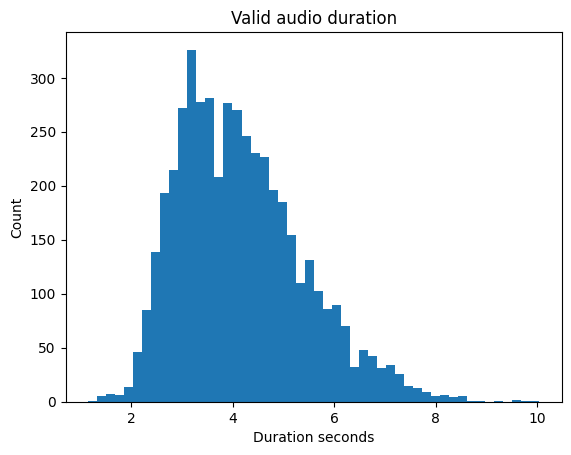

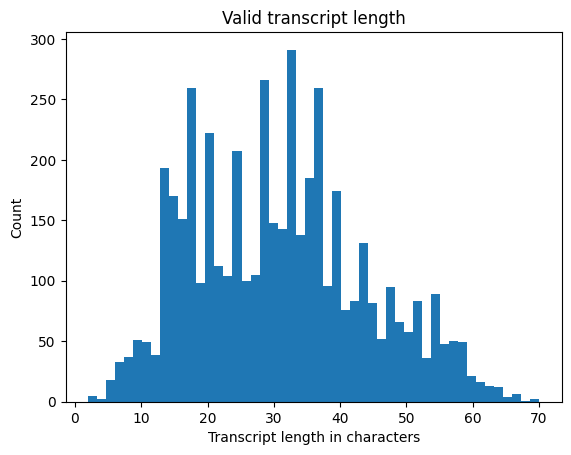

In [139]:
plt.hist(valid_df["duration_ms"].dropna() / 1000, bins=50)
plt.xlabel("Duration seconds")
plt.ylabel("Count")
plt.title("Valid audio duration")
plt.show()

plt.hist(valid_df["char_len"], bins=50)
plt.xlabel("Transcript length in characters")
plt.ylabel("Count")
plt.title("Valid transcript length")
plt.show()

### b. Split leakage
whether same sentence or speaker appears across train/valid/test

In [140]:
from itertools import combinations
train_texts = set(train_df["text_norm"])
valid_texts = set(valid_df["text_norm"])
test_texts = set(test_df["text_norm"])
dev_texts = set(dev_df["text_norm"])

texts_df = {
    "train": train_texts,
    "valid": valid_texts,
    "test": test_texts,
    "dev": dev_texts,
}
for df1, df2 in combinations(texts_df.keys(), 2):
    df1_texts = texts_df[df1]
    df2_texts = texts_df[df2]
    print(f"{df1}-{df2} text overlap:", len(df1_texts & df2_texts))

train_speakers = set(train_df["client_id"].dropna())
valid_speakers = set(valid_df["client_id"].dropna())
test_speakers = set(test_df["client_id"].dropna())
dev_speakers = set(dev_df["client_id"].dropna())

speakers_df = {
    "train": train_speakers,
    "valid": valid_speakers,
    "test": test_speakers,
    "dev": dev_speakers,
}
for df1, df2 in combinations(speakers_df.keys(), 2):
    df1_texts = speakers_df[df1]
    df2_texts = speakers_df[df2]
    print(f"{df1}-{df2} speaker overlap:", len(df1_texts & df2_texts))

train-valid text overlap: 1524
train-test text overlap: 7
train-dev text overlap: 5
valid-test text overlap: 957
valid-dev text overlap: 1212
test-dev text overlap: 2
train-valid speaker overlap: 6
train-test speaker overlap: 2
train-dev speaker overlap: 4
valid-test speaker overlap: 153
valid-dev speaker overlap: 6
test-dev speaker overlap: 0


In [141]:
train_texts & valid_texts & test_texts & dev_texts

set()

In [142]:
for name, df in [("train", train_df), ("valid", valid_df), ("test", test_df), ("dev", dev_df)]:
    print(name, "duplicate paths:", df["path"].duplicated().sum())

train duplicate paths: 0
valid duplicate paths: 0
test duplicate paths: 0
dev duplicate paths: 0


### c. Audio quality
- sample rate
- channels
- volume too low
- clipping
- long silence
- corrupted audio

In [143]:
# Safer audio EDA helper. It will not crash the notebook if one file is corrupted.
def audio_stats(path, target_sr=16000):
    try:
        y, sr = librosa.load(path, sr=target_sr, mono=True)

        duration = len(y) / sr
        max_amp = float(np.max(np.abs(y))) if len(y) > 0 else 0.0
        rms = float(np.sqrt(np.mean(y ** 2))) if len(y) > 0 else 0.0
        zero_ratio = float(np.mean(np.abs(y) < 1e-4)) if len(y) > 0 else 1.0

        return pd.Series({
            "load_ok": True,
            "duration_librosa": duration,
            "max_amp": max_amp,
            "rms": rms,
            "near_silence_ratio": zero_ratio,
        })
    except Exception as e:
        return pd.Series({
            "load_ok": False,
            "duration_librosa": None,
            "max_amp": None,
            "rms": None,
            "near_silence_ratio": None,
            "audio_error": str(e)[:200],
        })

sample_df = train_df.sample(min(500, len(train_df)), random_state=RANDOM_STATE).copy()
stats_df = sample_df["audio_path"].apply(audio_stats)
sample_df = pd.concat([sample_df, stats_df], axis=1)

sample_df[["audio_path", "text", "load_ok", "duration_librosa", "max_amp", "rms", "near_silence_ratio"]].head()


,audio_path,text,load_ok,duration_librosa,max_amp,rms,near_silence_ratio
1083,./cv-corpus-25.0-2026-03-09/vi/clips/common_vo...,Chinh cảm ơn xong trai để đứng dậy thanh toán ...,True,6.660,0.866654,0.097401,0.055659
787,./cv-corpus-25.0-2026-03-09/vi/clips/common_vo...,Hà thở dài rồi đáp,True,3.960,0.672514,0.071843,0.130603
845,./cv-corpus-25.0-2026-03-09/vi/clips/common_vo...,Mẹ em liền hỏi,True,3.168,0.622299,0.075876,0.139816
1701,./cv-corpus-25.0-2026-03-09/vi/clips/common_vo...,Từ đấy thu rồi thu lại thu,True,4.356,0.445950,0.045703,0.109461
1795,./cv-corpus-25.0-2026-03-09/vi/clips/common_vo...,Cô bạn càng lo,True,3.528,0.740199,0.070703,0.126027


In [144]:
# Handles corrupted file, very low volume, long silence, too short, too long, clipping
bad_audio = sample_df[
    (sample_df["load_ok"] == False) |
    (sample_df["rms"] < 0.005) |
    (sample_df["near_silence_ratio"] > 0.8)
]

bad_audio[["audio_path", "text", "rms", "near_silence_ratio"]].head(20)

,audio_path,text,rms,near_silence_ratio


### d. Audio-Text length ratio
Inspect long silence or sped up

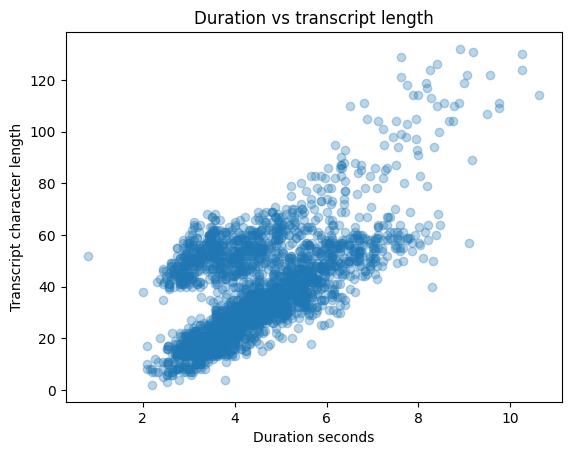

In [145]:
train_df["duration_sec"] = train_df["duration_ms"] / 1000
train_df["chars_per_sec"] = train_df["char_len"] / train_df["duration_sec"]
train_df["words_per_sec"] = train_df["word_len"] / train_df["duration_sec"]

plt.scatter(train_df["duration_sec"], train_df["char_len"], alpha=0.3)
plt.xlabel("Duration seconds")
plt.ylabel("Transcript character length")
plt.title("Duration vs transcript length")
plt.show()

In [146]:
outliers = train_df[
    (train_df["chars_per_sec"] < 2) |
    (train_df["chars_per_sec"] > 30)
]

outliers[["audio_path", "text", "duration_sec", "char_len", "chars_per_sec"]].head(20)

,audio_path,text,duration_sec,char_len,chars_per_sec
121,./cv-corpus-25.0-2026-03-09/vi/clips/common_vo...,được,2.784000,4,1.436782
425,./cv-corpus-25.0-2026-03-09/vi/clips/common_vo...,#NAME?,3.780000,4,1.058201
856,./cv-corpus-25.0-2026-03-09/vi/clips/common_vo...,Anh đã,3.060000,6,1.960784
1146,./cv-corpus-25.0-2026-03-09/vi/clips/common_vo...,Mẹ,2.196000,2,0.910747
1149,./cv-corpus-25.0-2026-03-09/vi/clips/common_vo...,Này,2.520000,3,1.190476
2190,./cv-corpus-25.0-2026-03-09/vi/clips/VIVOSSPK4...,ĐÓ LÀ CƠ HỘI ĐỂ NÂNG CAO GIÁ TRỊ CHÍNH BẢN THÂ...,0.811875,52,64.049269


### e. Speaker / accent / gender distribution

In [147]:
for col in ["client_id", "gender", "accents", "age", "up_votes", "down_votes"]:
    if col in train_df.columns:
        print("\n", col)
        print(train_df[col].value_counts(dropna=False).head(20))


 client_id
client_id
c14ad590de005be3a512e187900c5ad5c76921cf1883b3349cda8e57e390901f453aae312b3c027b31acc18b7e2f3e857b8f8618ab1eb3a0be7298f8d1c001ce    1887
VIVOSSPK46                                                                                                                           300
VIVOSSPK44                                                                                                                           300
VIVOSSPK37                                                                                                                           131
VIVOSDEV16                                                                                                                            40
c29d07b14c1806169f49b175b3bc29a620bd2d4c2291a4f8ecbe7dfbaf53fb40f990ebe6617dd1c281d09718ffab9a69d2fb615d19ba084288ba13d134253426       5
bb99c0461bef56ce3ce86b249c3c08535a13f40084a6960c83cd1f6a122d3637d8d44b0aa4d0c5d0bf9eff39d77bf22d329dc0d0b0924aa3ae0af763e3c0e23f       4
7fcc751f9092083e886

In [148]:
print("Unique train speakers:", train_df["client_id"].nunique())
print("Unique valid speakers:", valid_df["client_id"].nunique())

train_speakers = set(train_df["client_id"].dropna())
valid_speakers = set(valid_df["client_id"].dropna())

print("Speaker overlap train-valid:", len(train_speakers & valid_speakers))

Unique train speakers: 13
Unique valid speakers: 160
Speaker overlap train-valid: 6


## 4. Re-splitting datasets

### a. From CommonVoice

In [149]:
from sklearn.model_selection import GroupShuffleSplit

def make_group_split_close_to_ratio(
    df,
    group_col,
    test_size,
    random_state=42,
    n_trials=100
):
    best_score = float("inf")
    best_split = None

    target_test_rows = len(df) * test_size

    for seed in range(random_state, random_state + n_trials):
        gss = GroupShuffleSplit(
            n_splits=1,
            test_size=test_size,
            random_state=seed
        )

        train_idx, test_idx = next(gss.split(df, groups=df[group_col]))

        test_rows = len(test_idx)
        score = abs(test_rows - target_test_rows)

        if score < best_score:
            best_score = score
            best_split = (train_idx, test_idx, seed)

    return best_split

df = pd.concat([train_df, valid_df, test_df, dev_df], ignore_index=True).drop_duplicates()
df["duration_sec"] = df["duration_ms"] / 1000
df["chars_per_sec"] = df["text_norm"].str.len() / df["duration_sec"]

df = df[
    (df["duration_sec"] >= 0.5) &
    (df["duration_sec"] <= 18.0) &
    (df["chars_per_sec"] >= 1.0) &
    (df["chars_per_sec"] <= 28.0)
].reset_index(drop=True)

MAX_CHAR_LEN = 160
MAX_WORD_LEN = 35

df = df[
    (df["text_norm"].str.len() > 0) &
    (df["char_len"] <= MAX_CHAR_LEN) &
    (df["word_len"] <= MAX_WORD_LEN)
].reset_index(drop=True)

df["speaker_group"] = df["client_id"].fillna(df["path"])

train_idx, valid_idx, seed1 = make_group_split_close_to_ratio(
    df=df,
    group_col="speaker_group",
    test_size=0.25,
    random_state=RANDOM_STATE,
    n_trials=200
)

train_df = df.iloc[train_idx].reset_index(drop=True)
valid_df = df.iloc[valid_idx].reset_index(drop=True)

# train_idx, valid_idx, seed2 = make_group_split_close_to_ratio(
#     df=train_valid_df,
#     group_col="speaker_group",
#     test_size=0.25,
#     random_state=RANDOM_STATE + 1000,
#     n_trials=200
# )

# train_df = train_valid_df.iloc[train_idx].reset_index(drop=True)
# valid_df = train_valid_df.iloc[valid_idx].reset_index(drop=True)

print("Seed1:", seed1)
# print("Seed2:", seed2)

print("Train:", len(train_df))
print("Valid:", len(valid_df))
# print("Test:", len(test_df))

print("Train speakers:", train_df["speaker_group"].nunique())
print("Valid speakers:", valid_df["speaker_group"].nunique())
# print("Test speakers:", test_df["speaker_group"].nunique())

print(
    "train-valid speaker overlap:",
    len(set(train_df["speaker_group"]) & set(valid_df["speaker_group"]))
)
# print(
#     "train-test speaker overlap:",
#     len(set(train_df["speaker_group"]) & set(test_df["speaker_group"]))
# )
# print(
#     "valid-test speaker overlap:",
#     len(set(valid_df["speaker_group"]) & set(test_df["speaker_group"]))
# )

Seed1: 160
Train: 6003
Valid: 2022
Train speakers: 125
Valid speakers: 42
train-valid speaker overlap: 0


### b. Combine with VIVOS

In [150]:
train_df["source"] = "common_voice"
valid_df["source"] = "common_voice"
if RUN_ASR:
    cv_train_df = train_df.copy()
    cv_valid_df = valid_df.copy()

    vivos_train_df = vivos_train_df.reindex(columns=cv_train_df.columns)
    
    train_df = pd.concat(
        [cv_train_df, vivos_train_df],
        ignore_index=True
    ).sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)
    
    valid_df = cv_valid_df.copy()
    
    print("Combined train rows:", len(train_df))
    print(train_df["source"].value_counts())
    
    print("Validation rows:", len(valid_df))
    print(valid_df["source"].value_counts())

Combined train rows: 16932
source
vivos           10929
common_voice     6003
Name: count, dtype: int64
Validation rows: 2022
source
common_voice    2022
Name: count, dtype: int64


## 5. Tokenize

### a. Character tokenizer

Special tokens:
- `<pad>`: padding
- `<sos>`: start of sentence
- `<eos>`: end of sentence
- `<unk>`: unknown character

The tokenizer is fitted on the **training set only**.


In [151]:
from dataclasses import dataclass
from collections import Counter

PAD_TOKEN = "<pad>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"
UNK_TOKEN = "<unk>"

@dataclass
class CharTokenizer:
    stoi: dict
    itos: dict
    pad_id: int
    sos_id: int
    eos_id: int
    unk_id: int
    tokenizer_type: str = "char"

    def encode(self, text, add_sos_eos=True):
        ids = [self.stoi.get(ch, self.unk_id) for ch in str(text)]
        if add_sos_eos:
            ids = [self.sos_id] + ids + [self.eos_id]
        return ids

    def decode(self, ids):
        chars = []
        for idx in ids:
            idx = int(idx)
            if idx in [self.pad_id, self.sos_id]:
                continue
            if idx == self.eos_id:
                break
            chars.append(self.itos.get(idx, UNK_TOKEN))
        return "".join(chars)

    def __len__(self):
        return len(self.stoi)

def build_char_tokenizer(texts):
    vocab = sorted(set("".join([str(text) for text in texts])))
    tokens = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN] + vocab

    stoi = {token: idx for idx, token in enumerate(tokens)}
    itos = {idx: token for token, idx in stoi.items()}

    return CharTokenizer(
        stoi=stoi,
        itos=itos,
        pad_id=stoi[PAD_TOKEN],
        sos_id=stoi[SOS_TOKEN],
        eos_id=stoi[EOS_TOKEN],
        unk_id=stoi[UNK_TOKEN],
    )

print("Special tokens are defined.")

Special tokens are defined.


### b. Syllable tokenizer

The notebook now supports two active baseline tokenizers:

1. **Character tokenizer**: safest, no OOV problem, longest target sequence.
2. **Syllable tokenizer**: shorter target sequence for Vietnamese, but `min_freq > 1` creates `<unk>` tokens.

For debugging and tiny-overfit checks, use syllable `MIN_SYLLABLE_FREQ = 1`. After the pipeline is stable, you can try `MIN_SYLLABLE_FREQ = 2`, but exact round-trip decoding will no longer be guaranteed.


In [152]:
from dataclasses import dataclass
from collections import Counter

# Vietnamese text is written in syllable-like space-separated units.
# Example: "sinh viên" has two written syllables but one semantic word.
# This tokenizer uses those written syllables as tokens.

@dataclass
class SyllableTokenizer:
    stoi: dict
    itos: dict
    pad_id: int
    sos_id: int
    eos_id: int
    unk_id: int
    min_freq: int = 1
    tokenizer_type: str = "syllable"

    def encode(self, text, add_sos_eos=True):
        units = str(text).strip().split()
        ids = [self.stoi.get(unit, self.unk_id) for unit in units]

        if add_sos_eos:
            ids = [self.sos_id] + ids + [self.eos_id]

        return ids

    def decode(self, ids):
        units = []

        for idx in ids:
            idx = int(idx)

            if idx in [self.pad_id, self.sos_id]:
                continue

            if idx == self.eos_id:
                break

            units.append(self.itos.get(idx, UNK_TOKEN))

        return " ".join([unit for unit in units if unit])

    def __len__(self):
        return len(self.stoi)

def build_syllable_tokenizer(texts, min_freq=1):
    counter = Counter()

    for text in texts:
        counter.update(str(text).strip().split())

    vocab = sorted([
        unit for unit, count in counter.items()
        if count >= min_freq
    ])

    tokens = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN] + vocab

    stoi = {token: idx for idx, token in enumerate(tokens)}
    itos = {idx: token for token, idx in stoi.items()}

    return SyllableTokenizer(
        stoi=stoi,
        itos=itos,
        pad_id=stoi[PAD_TOKEN],
        sos_id=stoi[SOS_TOKEN],
        eos_id=stoi[EOS_TOKEN],
        unk_id=stoi[UNK_TOKEN],
        min_freq=min_freq,
    )

# Choose exactly one tokenizer here.
# For debugging and tiny-overfit tests, use syllable min_freq=1 so decode(encode(text)) can match exactly.
# After the pipeline is stable, you may try min_freq=2, but then <unk> tokens are expected.
MIN_SYLLABLE_FREQ = 1          # use 1 for debugging; 2+ intentionally creates <unk>

### c. Sentence Tokenizer

In [153]:
import sentencepiece as spm

class SentencePieceTokenizer:
        tokenizer_type = "sentencepiece_bpe"

        def __init__(self, model_path):
            self.model_path = model_path
            self.sp = spm.SentencePieceProcessor()
            self.sp.load(model_path)

            self.pad_id = self.sp.pad_id()
            self.sos_id = self.sp.bos_id()
            self.eos_id = self.sp.eos_id()
            self.unk_id = self.sp.unk_id()

        def encode(self, text, add_sos_eos=True):
            ids = self.sp.encode(str(text), out_type=int)

            if add_sos_eos:
                ids = [self.sos_id] + ids + [self.eos_id]

            return ids

        def decode(self, ids):
            clean_ids = []

            for idx in ids:
                idx = int(idx)

                if idx in [self.pad_id, self.sos_id]:
                    continue

                if idx == self.eos_id:
                    break

                clean_ids.append(idx)

            return self.sp.decode(clean_ids)

        def __len__(self):
            return self.sp.get_piece_size()

if RUN_BPE_EXPERIMENT:
    BPE_TEXT_FILE = "/kaggle/working/vietnamese_train_text.txt"
    BPE_MODEL_PREFIX = "/kaggle/working/vi_bpe"
    BPE_MODEL_PATH = "/kaggle/working/vi_bpe.model"
    BPE_VOCAB_SIZE = 800

    with open(BPE_TEXT_FILE, "w", encoding="utf-8") as f:
        for text in train_df["text_norm"]:
            f.write(text + "\n")

    spm.SentencePieceTrainer.train(
        input=BPE_TEXT_FILE,
        model_prefix=BPE_MODEL_PREFIX,
        vocab_size=BPE_VOCAB_SIZE,
        character_coverage=0.9995,
        model_type="bpe",
        hard_vocab_limit=False,
        pad_id=0,
        bos_id=1,
        eos_id=2,
        unk_id=3,
        pad_piece=PAD_TOKEN,
        bos_piece=SOS_TOKEN,
        eos_piece=EOS_TOKEN,
        unk_piece=UNK_TOKEN
    )

    # To try BPE targets later, set:
    # tokenizer = SentencePieceTokenizer("vi_bpe.model")
    # Then rerun Dataset/DataLoader/model creation cells because VOCAB_SIZE changes.
else:
    print("Skipping optional BPE experiment. Set RUN_BPE_EXPERIMENT=True to train SentencePiece.")

Skipping optional BPE experiment. Set RUN_BPE_EXPERIMENT=True to train SentencePiece.


In [154]:
if TOKENIZER_TYPE == "char":
    tokenizer = build_char_tokenizer(train_df["text_norm"])
elif TOKENIZER_TYPE == "syllable":
    tokenizer = build_syllable_tokenizer(train_df["text_norm"], min_freq=MIN_SYLLABLE_FREQ)
elif TOKENIZER_TYPE == "bpe":
    tokenizer = SentencePieceTokenizer("/kaggle/working/vi_bpe.model")
else:
    raise ValueError("TOKENIZER_TYPE must be 'char', 'syllable', or 'bpe'")

print("Tokenizer type:", tokenizer.tokenizer_type)
print("Vocab size:", len(tokenizer))
if hasattr(tokenizer, "min_freq"):
    print("Syllable min_freq:", tokenizer.min_freq)

if hasattr(tokenizer, "stoi"):
    print("First 30 vocab items:")
    print(list(tokenizer.stoi.items())[:30])
elif getattr(tokenizer, "tokenizer_type", "") == "sentencepiece_bpe":
    print("First 30 BPE pieces:")
    print([tokenizer.sp.id_to_piece(i) for i in range(min(30, len(tokenizer)))])

Tokenizer type: sentencepiece_bpe
Vocab size: 800
First 30 BPE pieces:
['<pad>', '<sos>', '<eos>', '<unk>', 'ng', '▁t', '▁c', 'nh', '▁đ', '▁m', '▁l', '▁th', '▁ch', '▁b', '▁v', '▁n', '▁nh', '▁k', '▁h', '▁ng', '▁kh', '▁s', '▁g', '▁tr', '▁r', 'ông', '▁là', 'ời', 'ên', '▁không']


Check one encoded target.

The model target shape before batching is:

```
[target_length]
```

Example:

```
<sos> x i n   c h à o <eos>
```


### d. Token health check

count    16932.000000
mean        17.536676
std          9.263270
min          3.000000
25%         11.000000
50%         15.000000
75%         22.000000
max         57.000000
Name: token_len, dtype: float64


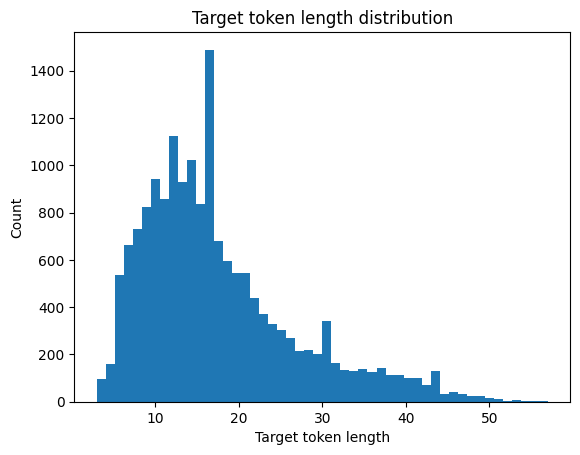

In [155]:
train_df["token_len"] = train_df["text_norm"].apply(lambda x: len(tokenizer.encode(x)))

print(train_df["token_len"].describe())

plt.hist(train_df["token_len"], bins=50)
plt.xlabel("Target token length")
plt.ylabel("Count")
plt.title("Target token length distribution")
plt.show()

In [156]:
def unk_rate(text):
    ids = tokenizer.encode(text)
    return ids.count(tokenizer.unk_id) / max(1, len(ids))

train_df["unk_rate"] = train_df["text_norm"].apply(unk_rate)

print(train_df["unk_rate"].describe())
print(train_df[train_df["unk_rate"] > 0][["text_norm", "unk_rate"]].head(20))

count    16932.000000
mean         0.001806
std          0.009896
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.142857
Name: unk_rate, dtype: float64
                                             text_norm  unk_rate
1    người miền bắc cứ hễ yêu ai là bắt phải về nhà...  0.052632
39   đến khi tóc đã pha sương tôi mới chịu ngồi lại...  0.030303
55   đồng thời người bệnh sẽ bị thiếu máu và dễ đôn...  0.052632
67   làm kỹ sư tôi chỉ nhận lương cao ngoài ra chẳn...  0.052632
72   nhan đề thư xin ghi rõ diễn đàn chương trình p...  0.041667
79   chúng tôi đều cúi đầu làm lễ chào tất cả mọi n...  0.052632
107  em thường xuyên xoa bóp đầu gối nhưng không dễ...  0.041667
109               ngay cả nền sản xuất hiện đại như mỹ  0.062500
154              tin tưởng vào lớp đạo diễn trẻ có tài  0.055556
160  qua bốn tuần sao mai điểm hẹn ưu thế nghiêng v...  0.034483
227  bài phát biểu khai mạc lễ kỉ niệm nhà giáo việ...  0.043478
254          

In [157]:
def tokenizer_unk_count(tokenizer, ids):
    return sum(1 for idx in ids if int(idx) == tokenizer.unk_id)

def tokenizer_roundtrip_report(tokenizer, text):
    ids = tokenizer.encode(text)
    decoded = tokenizer.decode(ids)
    unk_count = tokenizer_unk_count(tokenizer, ids)

    print("Tokenizer type:", getattr(tokenizer, "tokenizer_type", type(tokenizer).__name__))
    print("Text:", text)
    print("Token IDs:", ids)
    print("Decoded:", decoded)
    print("Target length:", len(ids))
    print("UNK count:", unk_count)

    if unk_count == 0:
        if decoded.strip() != text.strip():
            print("Warning: decoded text differs after BPE roundtrip")
            print("Original:", repr(text))
            print("Decoded:", repr(decoded))
    else:
        print("Decoded text differs because some tokens are <unk>.")

sample_text = train_df.loc[0, "text_norm"]
tokenizer_roundtrip_report(tokenizer, sample_text)

Tokenizer type: sentencepiece_bpe
Text: ăn nói sờm sỡ
Token IDs: [1, 310, 73, 21, 739, 721, 21, 797, 2]
Decoded: ăn nói sờm sỡ
Target length: 9
UNK count: 0


In [158]:
def count_oov_rows(df, tokenizer):
    temp = df.copy()
    temp["unk_count"] = temp["text_norm"].apply(
        lambda x: tokenizer.encode(x).count(tokenizer.unk_id)
    )
    temp["has_unk"] = temp["unk_count"] > 0
    return temp

train_oov = count_oov_rows(train_df, tokenizer)
valid_oov = count_oov_rows(valid_df, tokenizer)
# test_oov = count_oov_rows(test_df, tokenizer)

print("Train OOV rows:", train_oov["has_unk"].sum(), "/", len(train_oov))
print("Valid OOV rows:", valid_oov["has_unk"].sum(), "/", len(valid_oov))
# print("Test OOV rows:", test_oov["has_unk"].sum(), "/", len(test_oov))

display(valid_oov[valid_oov["has_unk"]][
    ["text_norm", "unk_count"]
].head(20))

Train OOV rows: 660 / 16932
Valid OOV rows: 50 / 2022


,text_norm,unk_count
34,rất dễ làm trẻ bị dị ứng mẩn ngứa thậm chí lên...,2
40,vì trong khi thi nhầm lẫn trong đề thi là rất dễ,1
52,lễ trao giải và cách thức phát giải có hứa hẹn,1
67,giảm thuế nhập khẩu để tránh tăng giá xăng tro...,1
69,thế là họ lo không biết có phải bị nhiễm từ ng...,1
83,mỹ thành lập khu bảo tồn biển lớn nhất thế giới,1
87,đây là nhà cung cấp bóng miễn phí cho toàn đội,1
92,nhưng giải càng vào sâu bóng đá nam mỹ càng hụ...,1
107,tại diễn đàn quốc hội ông đã nói được tiếng nó...,1
110,các bác sỹ đã cắt bỏ toàn bộ ngực của cô trong...,1


### e. Tokenizer OOV / UNK diagnostics

If you use syllable `min_freq > 1`, some target labels contain `<unk>`. That is not a data mismatch, but it can make training and overfit debugging harder.


In [159]:
def tokenizer_unk_rate(tokenizer, text):
    ids = tokenizer.encode(text)
    if len(ids) == 0:
        return 0.0
    return ids.count(tokenizer.unk_id) / len(ids)

for name, df in [("train", train_df), ("valid", valid_df)]:
    df["token_len"] = df["text_norm"].apply(lambda x: len(tokenizer.encode(x)))
    df["unk_rate"] = df["text_norm"].apply(lambda x: tokenizer_unk_rate(tokenizer, x))

    print("\n", name)
    print("token_len:")
    print(df["token_len"].describe())
    print("unk_rate:")
    print(df["unk_rate"].describe())
    print("rows with UNK:", (df["unk_rate"] > 0).sum())

train_df[train_df["unk_rate"] > 0][["text_norm", "token_len", "unk_rate"]].head(20)


 train
token_len:
count    16932.000000
mean        17.536676
std          9.263270
min          3.000000
25%         11.000000
50%         15.000000
75%         22.000000
max         57.000000
Name: token_len, dtype: float64
unk_rate:
count    16932.000000
mean         0.001806
std          0.009896
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.142857
Name: unk_rate, dtype: float64
rows with UNK: 660

 valid
token_len:
count    2022.000000
mean       14.139466
std         6.750031
min         3.000000
25%         9.000000
50%        13.000000
75%        17.000000
max        52.000000
Name: token_len, dtype: float64
unk_rate:
count    2022.000000
mean        0.001357
std         0.009109
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.100000
Name: unk_rate, dtype: float64
rows with UNK: 50


,text_norm,token_len,unk_rate
1,người miền bắc cứ hễ yêu ai là bắt phải về nhà...,19,0.052632
39,đến khi tóc đã pha sương tôi mới chịu ngồi lại...,33,0.030303
55,đồng thời người bệnh sẽ bị thiếu máu và dễ đôn...,19,0.052632
67,làm kỹ sư tôi chỉ nhận lương cao ngoài ra chẳn...,19,0.052632
72,nhan đề thư xin ghi rõ diễn đàn chương trình p...,24,0.041667
79,chúng tôi đều cúi đầu làm lễ chào tất cả mọi n...,19,0.052632
107,em thường xuyên xoa bóp đầu gối nhưng không dễ...,24,0.041667
109,ngay cả nền sản xuất hiện đại như mỹ,16,0.062500
154,tin tưởng vào lớp đạo diễn trẻ có tài,18,0.055556
160,qua bốn tuần sao mai điểm hẹn ưu thế nghiêng v...,29,0.034483


### f. BPE oversample

In [160]:
from collections import Counter

def oversample_rare_bpe_rows(
    train_df,
    tokenizer,
    text_col="text_norm",
    rare_token_max_count=10,
    max_repeat=2
):
    token_counter = Counter()

    special_ids = {
        tokenizer.pad_id,
        tokenizer.sos_id,
        tokenizer.eos_id,
        tokenizer.unk_id,
    }

    for text in train_df[text_col].astype(str):
        ids = tokenizer.encode(text)

        ids = [
            token_id for token_id in ids
            if token_id not in special_ids
        ]

        token_counter.update(ids)

    rare_token_ids = {
        token_id for token_id, count in token_counter.items()
        if count <= rare_token_max_count
    }

    def rare_token_count(text):
        ids = tokenizer.encode(str(text))

        ids = [
            token_id for token_id in ids
            if token_id not in special_ids
        ]

        return sum(1 for token_id in ids if token_id in rare_token_ids)

    scored_df = train_df.copy()
    scored_df["rare_bpe_count"] = scored_df[text_col].apply(rare_token_count)

    def get_repeat_count(count):
        if count <= 0:
            return 1
        elif count <= 2:
            return 2
        else:
            return max_repeat

    scored_df["repeat_count"] = scored_df["rare_bpe_count"].apply(get_repeat_count)

    oversampled_df = scored_df.loc[
        scored_df.index.repeat(scored_df["repeat_count"])
    ].sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

    print("Original train rows:", len(train_df))
    print("Oversampled train rows:", len(oversampled_df))
    print("Rare BPE token count:", len(rare_token_ids))

    rare_piece_examples = [
        tokenizer.sp.id_to_piece(token_id)
        for token_id in list(rare_token_ids)[:50]
    ]

    print("Rare BPE piece examples:")
    print(rare_piece_examples)

    display(
        scored_df.sort_values("rare_bpe_count", ascending=False)[
            ["text_norm", "rare_bpe_count", "repeat_count"]
        ].head(20)
    )

    return oversampled_df, scored_df, rare_token_ids, token_counter

## 6. Audio preprocessing

The model input is a **log-mel spectrogram**.

For one audio file:

```
waveform: [channels, samples]
log_mel:  [time_steps, n_mels]
```

For this baseline:

```
n_mels = 80
sample_rate = 16000
```


### a. Log-mel spectrums

This version loads `.mp3` audio with `librosa.load()` instead of `torchaudio.load()`.

Reason: on some Windows setups, newer `torchaudio.load()` calls TorchCodec internally, and TorchCodec may fail if FFmpeg/shared DLLs or torch/torchcodec versions are mismatched.


In [161]:
import torchaudio

SAMPLE_RATE = 16000
N_MELS = 80
N_FFT = 400
HOP_LENGTH = 160

class LogMelExtractor:
    def __init__(self, sample_rate=16000,
        n_mels=80, n_fft=400, hop_length=160, 
        speed_perturb=False,
        speed_choices=(0.9, 1.0, 1.1),
        speed_prob=0.8,
        min_aug_duration_sec=2.0,
        max_aug_duration_sec=18.0,
        pitch_augment=False,
        pitch_prob=0.35,
        pitch_steps_range=(-1.5, 1.5),
        noise_augment=False,
        noise_prob=0.3,
        reverb_prob=0.15,
        gain_prob=0.3,
    ):
        self.sample_rate = sample_rate
        self.speed_perturb = speed_perturb
        self.speed_choices = speed_choices
        self.speed_prob = speed_prob
        self.min_aug_duration_sec = min_aug_duration_sec
        self.max_aug_duration_sec = max_aug_duration_sec

        self.pitch_augment = pitch_augment
        self.pitch_prob = pitch_prob
        self.pitch_steps_range = pitch_steps_range
        
        self.noise_augment = noise_augment
        self.noise_prob = noise_prob
        self.reverb_prob = reverb_prob
        self.gain_prob = gain_prob

        self.mel = torchaudio.transforms.MelSpectrogram(
            sample_rate=sample_rate,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels
        )

    def apply_random_gain(self, audio_np, gain_db_range=(-6, 6)):
        gain_db = random.uniform(*gain_db_range)
        gain = 10 ** (gain_db / 20)
        return audio_np * gain

    def add_white_noise(self, audio_np, snr_db_range=(15, 30)):
        snr_db = random.uniform(*snr_db_range)

        signal_power = np.mean(audio_np ** 2) + 1e-9
        noise_power = signal_power / (10 ** (snr_db / 10))

        noise = np.random.normal(loc=0.0, scale=np.sqrt(noise_power), size=audio_np.shape).astype(np.float32)

        return audio_np + noise

    def apply_simple_reverb(self, audio_np):
        # Cheap artificial room echo using delayed copies.
        wet = audio_np.copy()

        delay_ms_list = [
            random.uniform(25, 45),
            random.uniform(55, 85),
            random.uniform(90, 130)
        ]

        gain_list = [
            random.uniform(0.20, 0.35),
            random.uniform(0.10, 0.25),
            random.uniform(0.05, 0.15)
        ]

        for delay_ms, gain in zip(delay_ms_list, gain_list):
            delay = int(self.sample_rate * delay_ms / 1000)

            if delay > 0 and delay < len(audio_np):
                wet[delay:] += gain * audio_np[:-delay]

        max_abs = np.max(np.abs(wet)) + 1e-9

        if max_abs > 1.0:
            wet = wet / max_abs

        return wet.astype(np.float32)

    def apply_pitch_shift(self, audio_np):
        # n_steps is semitones. Negative = lower voice, positive = higher voice
        n_steps = random.uniform(*self.pitch_steps_range)

        # Very small shifts are basically no-op
        if abs(n_steps) < 0.05:
            return audio_np
    
        shifted = librosa.effects.pitch_shift(
            audio_np.astype(np.float32),
            sr=self.sample_rate,
            n_steps=n_steps,
        )
        return shifted.astype(np.float32)

    def choose_safe_speed(self, duration_sec):
        """
        librosa.effects.time_stretch(y, rate=speed)
        new_duration = old_duration / speed

        We only allow speed values that keep the augmented audio
        inside [min_aug_duration_sec, max_aug_duration_sec].
        """

        safe_speeds = []

        for speed in self.speed_choices:
            new_duration = duration_sec / speed

            if (
                new_duration >= self.min_aug_duration_sec
                and new_duration <= self.max_aug_duration_sec
            ):
                safe_speeds.append(speed)

        if len(safe_speeds) == 0:
            return 1.0

        return random.choice(safe_speeds)
    
    def load_audio_without_torchcodec(self, path):
        try:
            audio_np, sr = librosa.load(
                path,
                sr=self.sample_rate,
                mono=True
            )

            duration_sec = len(audio_np) / self.sample_rate

            # 1) Speaking-rate augmentation
            if self.speed_perturb and random.random() < self.speed_prob:
                speed = self.choose_safe_speed(duration_sec)

                if speed != 1.0:
                    audio_np = librosa.effects.time_stretch(
                        audio_np,
                        rate=speed
                    )

            # 2) Low/High voice augmentation
            if self.pitch_augment and random.random() < self.pitch_prob:
                audio_np = self.apply_pitch_shift(audio_np)

            # 3) Recording background augmentation
            if self.noise_augment:
                if random.random() < self.gain_prob:
                    audio_np = self.apply_random_gain(audio_np)

                if random.random() < self.noise_prob:
                    audio_np = self.add_white_noise(audio_np)

                if random.random() < self.reverb_prob:
                    audio_np = self.apply_simple_reverb(audio_np)

            # Avoid clipping after all waveform-level augmentation
            max_abs = np.max(np.abs(audio_np)) + 1e-9
            if max_abs > 1.0:
                audio_np = audio_np / max_abs
                
        except Exception as e:
            raise RuntimeError(
                "Could not load audio with librosa. "
                "Install FFmpeg or convert Common Voice .mp3 clips to .wav first.\n"
                f"Original error: {e}"
            )

        waveform = torch.tensor(audio_np, dtype=torch.float32).unsqueeze(0)
        return waveform, self.sample_rate

    def __call__(self, path):
        waveform, sr = self.load_audio_without_torchcodec(path)

        mel = self.mel(waveform)
        log_mel = torch.log(mel + 1e-6)

        # [1, n_mels, time] -> [time, n_mels]
        log_mel = log_mel.squeeze(0).transpose(0, 1)

        log_mel = (log_mel - log_mel.mean(dim=0, keepdim=True)) / (
            log_mel.std(dim=0, keepdim=True) + 1e-5
        )

        return log_mel

train_feature_extractor = LogMelExtractor(
    sample_rate=SAMPLE_RATE,
    n_mels=N_MELS,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,

    # speaking-rate augmentation
    speed_perturb=True,
    speed_choices=SPEED_CHOICES,
    speed_prob=0.8,
    min_aug_duration_sec=2.0,
    max_aug_duration_sec=20.0,

    # Frequency augmentation
    pitch_augment=TRAIN_PITCH_OK,
    pitch_prob=0.1,
    pitch_steps_range=PITCH_STEPS_RANGE,

    # Recording-background augmentation
    noise_augment=TRAIN_NOISE_OK,
    noise_prob=0.25,
    reverb_prob=0.1,
    gain_prob=0.3
)

valid_feature_extractor = LogMelExtractor(
    sample_rate=SAMPLE_RATE,
    n_mels=N_MELS,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    speed_perturb=False,
    noise_augment=False
)

features = valid_feature_extractor(train_df.loc[0, "audio_path"])

print("Input spectrum shape:", features.shape)
print("Mean after normalization:", features.mean().item())
print("Std after normalization:", features.std().item())
print("Meaning: [time_steps, n_mels]")

Input spectrum shape: torch.Size([344, 80])
Mean after normalization: 1.3029852752310944e-08
Std after normalization: 0.9985598921775818
Meaning: [time_steps, n_mels]


### b. Visualization spectrum

In [162]:
def visualize_audio_spectrum(
    audio_path, text=None, feature_extractor=None, sample_rate=16000
):
    y, sr = librosa.load(audio_path, sr=sample_rate, mono=True)
    duration_sec = len(y) / sr

    print("Audio path:", audio_path)
    print("Duration:", round(duration_sec, 3), "sec")

    if text is not None:
        print("Text:", text)

    # 1. Waveform
    plt.figure(figsize=(12, 3))
    librosa.display.waveshow(y, sr=sr)
    plt.title("Waveform")
    plt.xlabel("Time (sec)")
    plt.ylabel("Amplitude")
    plt.show()

    # 2. STFT spectrogram
    stft = librosa.stft(y, n_fft=400, hop_length=160)
    stft_db = librosa.amplitude_to_db(np.abs(stft), ref=np.max)

    plt.figure(figsize=(12, 4))
    librosa.display.specshow(
        stft_db,
        sr=sr,
        hop_length=160,
        x_axis="time",
        y_axis="hz"
    )
    plt.colorbar(format="%+2.0f dB")
    plt.title("STFT Spectrogram")
    plt.xlabel("Time (sec)")
    plt.ylabel("Frequency (Hz)")
    plt.show()

    # 3. Mel spectrogram
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=400,
        hop_length=160,
        n_mels=80
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    plt.figure(figsize=(12, 4))
    librosa.display.specshow(
        mel_db,
        sr=sr,
        hop_length=160,
        x_axis="time",
        y_axis="mel"
    )
    plt.colorbar(format="%+2.0f dB")
    plt.title("Mel Spectrogram")
    plt.xlabel("Time (sec)")
    plt.ylabel("Mel bins")
    plt.show()

    # 4. Your model's final normalized log-mel input
    if feature_extractor is not None:
        log_mel = feature_extractor(audio_path)  # [T, 80]

        plt.figure(figsize=(12, 4))
        plt.imshow(
            log_mel.T.cpu().numpy(),
            aspect="auto",
            origin="lower"
        )
        plt.colorbar()
        plt.title("Model Input: Normalized Log-Mel")
        plt.xlabel("Time frames")
        plt.ylabel("Mel bins")
        plt.show()

        print("Model input shape:", log_mel.shape)

Audio path: /kaggle/input/datasets/kaleykim297/vivos-audio2/vivos/train/waves/VIVOSSPK38/VIVOSSPK38_075.wav
Duration: 5.344 sec
Text: cũng theo ông văn người dân được quyền khởi kiện tại tòa án nhân dân huyện long thành


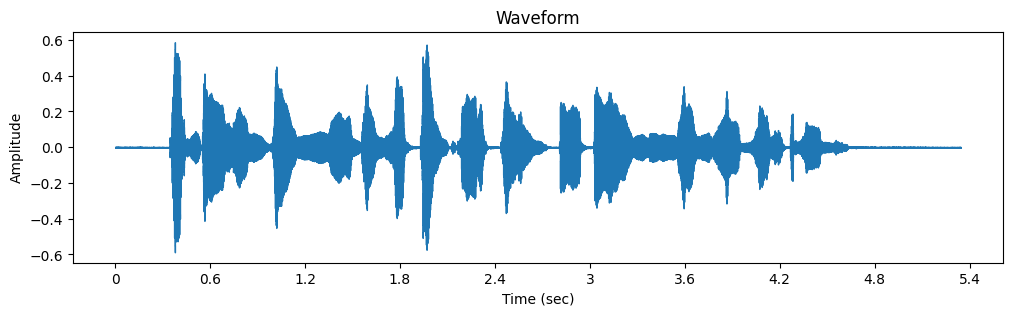

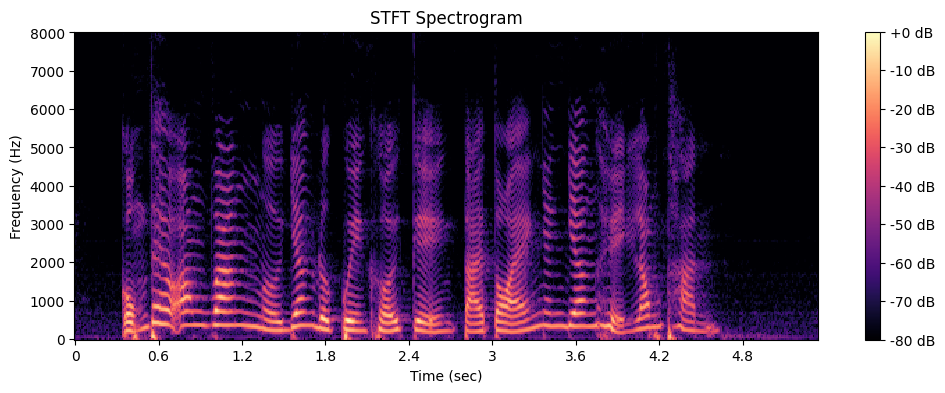

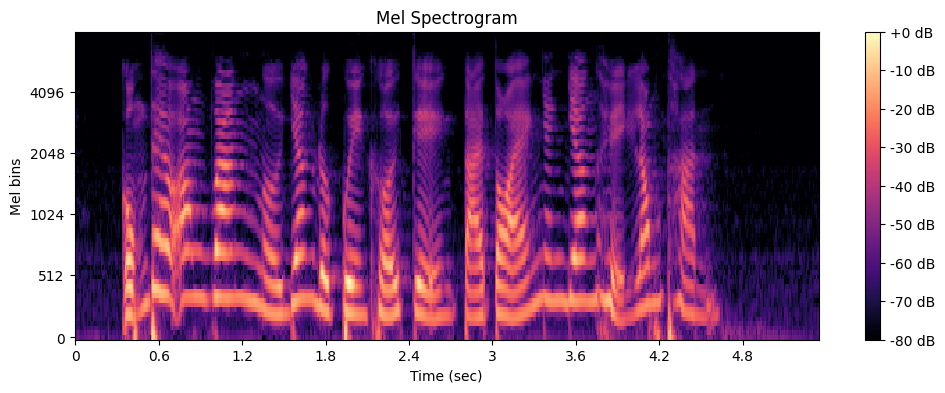

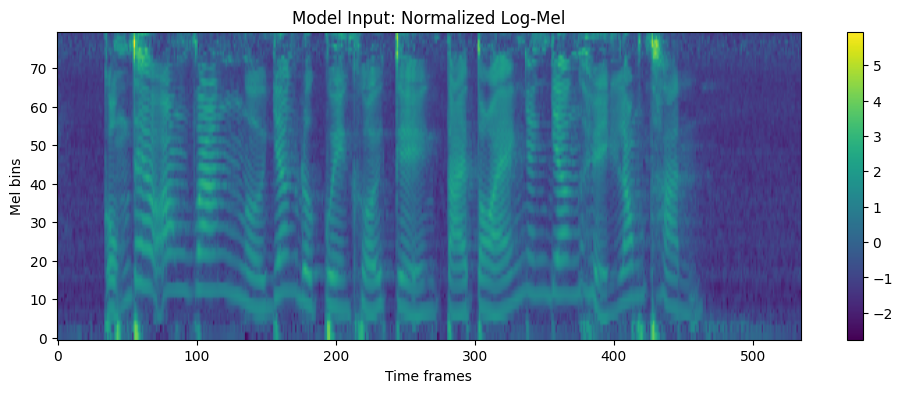

Model input shape: torch.Size([535, 80])


In [163]:
idx = train_df.sample(1, random_state=42).index[0]
row = train_df.loc[idx]

visualize_audio_spectrum(
    audio_path=row["audio_path"],
    text=row["text_norm"],
    feature_extractor=valid_feature_extractor,
    sample_rate=SAMPLE_RATE
)

## 7. Augmentation on train
Forces neural networks to treat audio inputs like images and artifically corrupting them during training so the model doesn't overfit

### a. SpecAugment

In [164]:
import torch
import torch.nn as nn

class SpecAugment(nn.Module):
    def __init__(
        self,
        freq_mask_param=12,
        time_mask_param=40,
        num_freq_masks=2,
        num_time_masks=3
    ):
        super().__init__()

        self.freq_mask_param = freq_mask_param
        self.time_mask_param = time_mask_param
        self.num_freq_masks = num_freq_masks
        self.num_time_masks = num_time_masks

    def forward(self, x):
        # x: [T, F]
        x = x.clone()
        time_steps, freq_bins = x.shape

        for _ in range(self.num_freq_masks):
            f = torch.randint(0, self.freq_mask_param + 1, (1,)).item()
            f0 = torch.randint(0, max(1, freq_bins - f + 1), (1,)).item()
            x[:, f0:f0 + f] = 0

        for _ in range(self.num_time_masks):
            t = torch.randint(0, self.time_mask_param + 1, (1,)).item()
            t0 = torch.randint(0, max(1, time_steps - t + 1), (1,)).item()
            x[t0:t0 + t, :] = 0

        return x

### b. Oversample with rare characters or words

In [165]:
from collections import Counter
import numpy as np

def build_rare_char_word_sets(
    train_df,
    text_col="text_norm",
    rare_char_max_count=20,
    rare_word_max_count=2,
    ignore_chars=(" ",)
):
    char_counter = Counter()
    word_counter = Counter()

    for text in train_df[text_col].astype(str):
        char_counter.update(text)
        word_counter.update(text.split())

    rare_chars = {
        ch for ch, count in char_counter.items()
        if count <= rare_char_max_count and ch not in ignore_chars
    }

    rare_words = {
        word for word, count in word_counter.items()
        if count <= rare_word_max_count
    }

    return char_counter, word_counter, rare_chars, rare_words


def add_rare_scores(
    df,
    rare_chars,
    rare_words,
    text_col="text_norm"
):
    df = df.copy()

    def rare_char_count(text):
        return sum(1 for ch in str(text) if ch in rare_chars)

    def rare_word_count(text):
        return sum(1 for word in str(text).split() if word in rare_words)

    df["rare_char_count"] = df[text_col].apply(rare_char_count)
    df["rare_word_count"] = df[text_col].apply(rare_word_count)

    # Rare words are stronger signal than rare characters.
    df["rare_score"] = (
        df["rare_char_count"] * 1.0 +
        df["rare_word_count"] * 2.0
    )

    return df


def oversample_rare_rows(
    train_df,
    text_col="text_norm",
    rare_char_max_count=20,
    rare_word_max_count=2,
    max_repeat=3
):
    char_counter, word_counter, rare_chars, rare_words = build_rare_char_word_sets(
        train_df=train_df,
        text_col=text_col,
        rare_char_max_count=rare_char_max_count,
        rare_word_max_count=rare_word_max_count
    )

    scored_df = add_rare_scores(
        df=train_df,
        rare_chars=rare_chars,
        rare_words=rare_words,
        text_col=text_col
    )

    def get_repeat_count(score):
        if score <= 0:
            return 1
        elif score <= 2:
            return 2
        else:
            return max_repeat

    scored_df["repeat_count"] = scored_df["rare_score"].apply(get_repeat_count)

    oversampled_df = scored_df.loc[
        scored_df.index.repeat(scored_df["repeat_count"])
    ].sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

    print("Original train rows:", len(train_df))
    print("Oversampled train rows:", len(oversampled_df))
    print("Rare chars:", sorted(list(rare_chars)))
    print("Number of rare words:", len(rare_words))

    display(
        scored_df.sort_values("rare_score", ascending=False)[
            ["text_norm", "rare_char_count", "rare_word_count", "rare_score", "repeat_count"]
        ].head(20)
    )

    return oversampled_df, scored_df, rare_chars, rare_words, char_counter, word_counter

In [166]:
# Rare characters oversample
# train_df_model, train_scored_df, rare_chars, rare_words, char_counter, word_counter = oversample_rare_rows(
#     train_df=train_df,
#     text_col="text_norm",
#     rare_char_max_count=20,
#     rare_word_max_count=2,
#     max_repeat=3
# )

# BPE oversample
train_df_model, train_bpe_scored_df, rare_bpe_token_ids, bpe_token_counter = oversample_rare_bpe_rows(
    train_df=train_df,
    tokenizer=tokenizer,
    text_col="text_norm",
    rare_token_max_count=10,
    max_repeat=3
)

Original train rows: 16932
Oversampled train rows: 17016
Rare BPE token count: 19
Rare BPE piece examples:
['ờng', '▁ku', '▁q', 'ph', 'ười', 'th', 'h', '▁kumanth', 'g', 'l', '▁đứ', 'r', 'b', 'k', 's', 'ấ', 'x', '▁kì', 'ện']


,text_norm,rare_bpe_count,repeat_count
4983,xoá ảnh trên facebook delete ảnh đã đăng trên ...,5,3
16696,xoá ảnh trên facebook delete ảnh đã đăng trên ...,5,3
1764,cách thiết lập để có cuộc gọi chất lượng cao t...,3,3
4811,mà nhắn tin qua facebook thì mới biết cũng khô...,2,2
2576,chỉ độ tầm chục người với năm con exciter năm ...,2,2
11954,mà nhắn tin qua facebook thì mới biết cũng khô...,2,2
8673,chỉ độ tầm chục người với năm con exciter năm ...,2,2
406,ện người có mang gần đến tháng đẻ đi ộn ện,2,2
5391,alo anh xăm trai phải không ạ,1,2
16298,ngày mai em qua shop xong sẽ ghé anh được chứ,1,2


## 8. PyTorch Dataset and DataLoader

Each item returns:

```
x:      [time_steps, 80]
y:      [target_length]
x_len:  scalar
y_len:  scalar
```

The collate function pads a batch into:

```
x_pad:  [batch_size, max_time_steps, 80]
y_pad:  [batch_size, max_target_length]
x_lens: [batch_size]
y_lens: [batch_size]
```

### a. CommonVoice

In [167]:
class SpeechTextDataset(Dataset):
    def __init__(self, dataframe, tokenizer, feature_extractor, augment=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.feature_extractor = feature_extractor
        self.augment = augment

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        x = self.feature_extractor(row["audio_path"])

        if self.augment is not None:
            x = self.augment(x)

        y = torch.tensor(
            self.tokenizer.encode(row["text_norm"]),
            dtype=torch.long
        )

        return {
            "x": x,
            "y": y,
            "x_len": x.size(0),
            "y_len": y.size(0),
            "text": row["text_norm"],
        }

def collate_speech_batch(batch):
    xs = [item["x"] for item in batch]
    ys = [item["y"] for item in batch]

    x_lens = torch.tensor([item["x_len"] for item in batch], dtype=torch.long)
    y_lens = torch.tensor([item["y_len"] for item in batch], dtype=torch.long)

    x_pad = pad_sequence(xs, batch_first=True, padding_value=0.0)
    y_pad = pad_sequence(ys, batch_first=True, padding_value=tokenizer.pad_id)

    texts = [item["text"] for item in batch]

    return x_pad, y_pad, x_lens, y_lens, texts

class DurationBucketBatchSampler(Sampler):
    """
    Groups audio clips with similar duration into the same batch.

    Why:
        Speech batches waste memory when a 2-second clip and a 15-second clip
        are padded to the same max length. Bucketing reduces padding.

    Important:
        Use this as DataLoader(batch_sampler=...), so do not also pass
        batch_size=... or shuffle=... to DataLoader.
    """
    def __init__(
        self,
        dataframe,
        batch_size,
        duration_col="duration_ms",
        bucket_size=128,
        shuffle=True,
        drop_last=False
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.batch_size = batch_size
        self.duration_col = duration_col
        self.bucket_size = bucket_size
        self.shuffle = shuffle
        self.drop_last = drop_last

        if duration_col not in self.dataframe.columns:
            raise ValueError(f"Missing duration column: {duration_col}")

        self.durations = self.dataframe[duration_col].fillna(0).tolist()

    def __iter__(self):
        indices = list(range(len(self.dataframe)))

        # Sort by duration first.
        indices = sorted(indices, key=lambda i: self.durations[i])

        # Split sorted indices into large buckets.
        buckets = [
            indices[i:i + self.bucket_size]
            for i in range(0, len(indices), self.bucket_size)
        ]

        if self.shuffle:
            random.shuffle(buckets)

        batches = []

        for bucket in buckets:
            if self.shuffle:
                random.shuffle(bucket)

            for i in range(0, len(bucket), self.batch_size):
                batch = bucket[i:i + self.batch_size]

                if len(batch) == self.batch_size or not self.drop_last:
                    batches.append(batch)

        if self.shuffle:
            random.shuffle(batches)

        for batch in batches:
            yield batch

    def __len__(self):
        n = len(self.dataframe)

        if self.drop_last:
            return n // self.batch_size

        return (n + self.batch_size - 1) // self.batch_size

BATCH_SIZE = 12
BUCKET_SIZE = 128

spec_augment = SpecAugment(freq_mask_param=10, time_mask_param=30, num_freq_masks=2, num_time_masks=2)

train_dataset = SpeechTextDataset(train_df_model, tokenizer, train_feature_extractor, augment=spec_augment)
valid_dataset = SpeechTextDataset(valid_df, tokenizer, valid_feature_extractor, augment=None)

train_bucket_sampler = DurationBucketBatchSampler(
    dataframe=train_dataset.dataframe,
    batch_size=BATCH_SIZE,
    duration_col="duration_ms",
    bucket_size=BUCKET_SIZE,
    shuffle=True,
    drop_last=False
)

valid_bucket_sampler = DurationBucketBatchSampler(
    dataframe=valid_dataset.dataframe,
    batch_size=BATCH_SIZE,
    duration_col="duration_ms",
    bucket_size=BUCKET_SIZE,
    shuffle=False,
    drop_last=False
)

train_loader = DataLoader(
    train_dataset,
    batch_sampler=train_bucket_sampler,
    collate_fn=collate_speech_batch
)

valid_loader = DataLoader(
    valid_dataset,
    batch_sampler=valid_bucket_sampler,
    collate_fn=collate_speech_batch
)

x_pad, y_pad, x_lens, y_lens, texts = next(iter(train_loader))

print("x_pad:", x_pad.shape, "=> [batch, time, n_mels]")
print("y_pad:", y_pad.shape, "=> [batch, target_length]")
print("x_lens:", x_lens)
print("y_lens:", y_lens)
print("texts:", texts)
print("Padding ratio in this batch:", 1 - (x_lens.sum().item() / (x_pad.size(0) * x_pad.size(1))))

x_pad: torch.Size([12, 545, 80]) => [batch, time, n_mels]
y_pad: torch.Size([12, 22]) => [batch, target_length]
x_lens: tensor([490, 542, 487, 488, 545, 490, 490, 487, 545, 490, 545, 488])
y_lens: tensor([ 8, 22, 11, 20, 12, 11, 15, 14, 13, 13, 15, 18])
texts: ['tôi hết đau rồi hay là', 'nỗi ám ảnh đó cứ kéo dài thành một vết rạn nứt thật lớn', 'em là bạn thân của nhi vợ của anh', 'cũng sẽ buộc hạ viện phải xem xét lại dự luật này', 'gió ngoài hiên cũng tắt tự khi nào', 'yêu là chết ở trong lòng một ít', 'có ta cầm trên tay một bó hoa dã quỳ khác', 'và ngồi bên đống củi lửa đang tàn', 'không chỉ cầu tiền tài may mắn không đâu', 'vì giữa đường không bắt được xe ôm khác', 'hình ảnh đứa bé có nước da đen sạm', 'với các chất liệu nhẹ nhàng như ren hay lụa']
Padding ratio in this batch: 0.06926605504587158


### b. VIVOS
Unsupervised

In [168]:
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

class UnlabeledSpeechDataset(Dataset):
    def __init__(self, dataframe, feature_extractor):
        self.dataframe = dataframe.reset_index(drop=True)
        self.feature_extractor = feature_extractor

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        audio_path = row["audio_path"]

        x = self.feature_extractor(audio_path)  # [T, 80]
        x_len = x.size(0)

        return x, x_len, audio_path


def collate_unlabeled_batch(batch):
    xs, x_lens, audio_paths = zip(*batch)

    x_lens = torch.tensor(x_lens, dtype=torch.long)
    x_pad = pad_sequence(xs, batch_first=True, padding_value=0.0)

    return x_pad, x_lens, audio_paths

In [169]:
if RUN_SSL_PRETRAINING:
    ssl_feature_extractor = LogMelExtractor(
        sample_rate=SAMPLE_RATE,
        n_mels=N_MELS,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        speed_perturb=False,
        speed_choices=(0.95, 1.0, 1.05),
        speed_prob=0.3,
        min_aug_duration_sec=2.0,
        max_aug_duration_sec=18.0,
        noise_augment=False,
        # noise_prob=0.10,
        # reverb_prob=0.05,
        # gain_prob=0.15
    )
    
    ssl_dataset = UnlabeledSpeechDataset(
        dataframe=vivos_df,
        feature_extractor=ssl_feature_extractor
    )
    
    SSL_BATCH_SIZE = 16
    
    ssl_loader = DataLoader(
        ssl_dataset,
        batch_size=SSL_BATCH_SIZE,
        shuffle=True,
        collate_fn=collate_unlabeled_batch,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
        persistent_workers=True
    )

## 9. Model architecture

We keep the 3 LAS blocks separated:

1. `Listener`
2. `AdditiveAttention`
3. `Speller`

Then `LASModel` connects them together.


### a. Subsampling
-> reduces time before BiLSTM
[batch, time, 80] → [batch, shorter_time, feature_dim]

In [170]:
import torch
import torch.nn as nn

class ConvSubsampler(nn.Module):
    def __init__(self, input_dim=80, conv_dim=128):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(
                in_channels=input_dim,
                out_channels=conv_dim,
                kernel_size=5,
                stride=2,
                padding=2
            ),
            nn.ReLU(),
            nn.Conv1d(
                in_channels=conv_dim,
                out_channels=conv_dim,
                kernel_size=5,
                stride=2,
                padding=2
            ),
            nn.ReLU()
        )

    def forward(self, x, lengths):
        # x: [B, T, F]
        x = x.transpose(1, 2)      # [B, F, T]
        x = self.conv(x)           # [B, C, T']
        x = x.transpose(1, 2)      # [B, T', C]

        # Two Conv1d layers with stride=2 reduce time by about 4x.
        lengths = torch.div(lengths + 3, 4, rounding_mode="floor")
        lengths = torch.clamp(lengths, min=1)

        return x, lengths


### b. Conformer

In [171]:
import torch.nn.functional as F

class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).float().unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)

        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)
        
        pe = pe.unsqueeze(0) # [1, max_len, d_model]
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: [B, T, C]
        return x + self.pe[:, :x.size(1), :]

class ConformerFeedForward(nn.Module):
    def __init__(self, d_model, expansion_factor=4, dropout=0.1):
        super().__init__()

        hidden_dim = d_model * expansion_factor
        self.net = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, d_model),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

class ConformerConvModule(nn.Module):
    def __init__(self, d_model, kernel_size=15, dropout=0.1):
        super().__init__()

        if kernel_size % 2 == 0:
            raise ValueError("Conformer convolution kernel_size should be odd.")
        self.layer_norm = nn.LayerNorm(d_model)

        self.pointwise_conv1 = nn.Conv1d(
            in_channels=d_model,
            out_channels=2*d_model,
            kernel_size=1
        )

        self.depthwise_conv = nn.Conv1d(
            in_channels=d_model,
            out_channels=d_model,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
            groups=d_model,
        )

        self.batch_norm = nn.BatchNorm1d(d_model)

        self.pointwise_conv2 = nn.Conv1d(
            in_channels=d_model,
            out_channels=d_model,
            kernel_size=1,
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: [B, T, C]
        x = self.layer_norm(x)
        x = x.transpose(1, 2) # [B, C, T]

        x = self.pointwise_conv1(x)
        x = F.glu(x, dim=1) # [B, C, T]

        x = self.depthwise_conv(x)
        x = self.batch_norm(x)
        x = F.silu(x)

        x = self.pointwise_conv2(x)
        x = self.dropout(x)

        x = x.transpose(1, 2) # [B, T, C]

        return x

class ConformerBlock(nn.Module):
    def __init__(
        self, d_model,
        num_heads=4, ff_expansion_factor=4,
        conv_kernel_size=15,
        dropout=0.1
    ):
        super().__init__()

        self.ffn1 = ConformerFeedForward(
            d_model=d_model,
            expansion_factor=ff_expansion_factor,
            dropout=dropout
        )

        self.self_attn_norm = nn.LayerNorm(d_model)

        self.self_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.self_attn_dropout = nn.Dropout(dropout)

        self.conv_module = ConformerConvModule(
            d_model=d_model,
            kernel_size=conv_kernel_size,
            dropout=dropout
        )

        self.ffn2 = ConformerFeedForward(
            d_model=d_model,
            expansion_factor=ff_expansion_factor,
            dropout=dropout,
        )

        self.final_norm = nn.LayerNorm(d_model)

    def forward(self, x, padding_mask):
        # x: [B, T, C]
        # padding_mask: [B, T], True means padded frame
        x = x + 0.5 * self.ffn1(x)

        attn_input = self.self_attn_norm(x)

        attn_out, _ = self.self_attn(
            query=attn_input,
            key=attn_input,
            value=attn_input,
            key_padding_mask=padding_mask,
            need_weights=False,
        )

        x = x + self.self_attn_dropout(attn_out)
        x = x + self.conv_module(x)
        x = x + 0.5 * self.ffn2(x)
        x = self.final_norm(x)

        return x

class ConformerEncoder(nn.Module):
    def __init__(
        self, input_dim=80,
        d_model=128, 
        num_layers=4, num_heads=4,
        ff_expansion_factor=4,
        conv_kernel_size=15,
        dropout=0.1
    ):
        super().__init__()

        self.subsampler = ConvSubsampler(
            input_dim=input_dim,
            conv_dim=d_model
        )

        self.pos_encoding = SinusoidalPositionalEncoding(d_model)

        self.layers = nn.ModuleList([
            ConformerBlock(
                d_model=d_model,
                num_heads=num_heads,
                ff_expansion_factor=ff_expansion_factor,
                conv_kernel_size=conv_kernel_size,
                dropout=dropout
            )
            for _ in range(num_layers)
        ])

        self.final_norm = nn.LayerNorm(d_model)
    
    def make_padding_mask(self, lengths, max_len):
        time_ids = torch.arange(max_len, device=lengths.device).unsqueeze(0)
        return time_ids >= lengths.unsqueeze(1)

    def forward(self, x, lengths):
        # x: [B, T, 80]
        # lengths: [B]
        out, out_lens = self.subsampler(x, lengths)
        # out: [B, T/4, d_model]

        out = self.pos_encoding(out)

        padding_mask = self.make_padding_mask(
            lengths=out_lens,
            max_len=out.size(1)
        )

        for layer in self.layers:
            out = layer(out, padding_mask)

        out = self.final_norm(out)

        return out, out_lens

### c. Listener

The listener is a pyramidal BiLSTM encoder.

Input:

```
x:      [batch, time, input_dim]
x_lens: [batch]
```

Output:

```
encoder_out:  [batch, reduced_time, encoder_dim]
encoder_lens: [batch]
```

Because we reduce time between LSTM layers, the output sequence becomes shorter.


In [172]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

class Listener(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers=2, dropout=0.1):
        super().__init__()

        self.subsampler = ConvSubsampler(
            input_dim=input_dim,
            conv_dim=hidden_dim
        )

        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        self.rnns = nn.ModuleList()

        # Important:
        # After ConvSubsampler, feature dimension is hidden_dim, not input_dim.
        self.rnns.append(
            nn.LSTM(
                input_size=hidden_dim,
                hidden_size=hidden_dim,
                batch_first=True,
                bidirectional=True
            )
        )

        # Later layers receive concatenated pairs from the previous BiLSTM output:
        # previous feature dim = hidden_dim * 2
        # after pyramid_reduce, feature dim = hidden_dim * 4
        for _ in range(1, num_layers):
            self.rnns.append(
                nn.LSTM(
                    input_size=hidden_dim * 4,
                    hidden_size=hidden_dim,
                    batch_first=True,
                    bidirectional=True
                )
            )

        self.dropout = nn.Dropout(dropout)

    def pyramid_reduce(self, x, lengths):
        # x: [B, T, F]
        batch_size, time_steps, feature_dim = x.shape

        if time_steps % 2 == 1:
            x = x[:, :-1, :]
            time_steps = time_steps - 1

        x = x.contiguous().view(batch_size, time_steps // 2, feature_dim * 2)
        lengths = torch.clamp(lengths // 2, min=1)

        return x, lengths

    def forward(self, x, lengths):
        # First reduce acoustic time resolution with CNN.
        out, out_lens = self.subsampler(x, lengths)

        for layer_idx, rnn in enumerate(self.rnns):
            packed = pack_padded_sequence(
                out,
                out_lens.cpu(),
                batch_first=True,
                enforce_sorted=False
            )

            packed_out, _ = rnn(packed)

            out, _ = pad_packed_sequence(
                packed_out,
                batch_first=True
            )

            out = self.dropout(out)

            # Reduce time after every layer except the final layer.
            if layer_idx < self.num_layers - 1:
                out, out_lens = self.pyramid_reduce(out, out_lens)

        return out, out_lens

### d. Speller

The speller predicts one output token at a time.

Depending on your active tokenizer, a token may be:
- one character
- one Vietnamese written syllable
- one BPE subword piece

During training:
- sometimes it receives the correct previous token
- sometimes it receives its own previous prediction

This is called **teacher forcing**.


In [173]:
class AdditiveAttention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super().__init__()

        self.encoder_proj = nn.Linear(encoder_dim, attention_dim)
        self.decoder_proj = nn.Linear(decoder_dim, attention_dim)
        self.score = nn.Linear(attention_dim, 1)

    def make_mask(self, encoder_out, encoder_lens):
        batch_size, max_time, _ = encoder_out.shape
        time_ids = torch.arange(max_time, device=encoder_out.device).unsqueeze(0)
        return time_ids >= encoder_lens.unsqueeze(1)

    def forward(self, decoder_hidden, encoder_out, encoder_lens):
        encoder_energy = self.encoder_proj(encoder_out)
        decoder_energy = self.decoder_proj(decoder_hidden).unsqueeze(1)

        energy = torch.tanh(encoder_energy + decoder_energy)
        scores = self.score(energy).squeeze(-1)

        mask = self.make_mask(encoder_out, encoder_lens)
        scores = scores.masked_fill(mask, -1e9)

        attention_weights = torch.softmax(scores, dim=-1)

        context = torch.bmm(
            attention_weights.unsqueeze(1),
            encoder_out
        ).squeeze(1)

        return context, attention_weights

In [174]:
# class Speller(nn.Module):
#     def __init__(
#         self,
#         vocab_size,
#         encoder_dim,
#         embedding_dim,
#         decoder_dim,
#         attention_dim,
#         pad_id,
#         sos_id,
#         eos_id,
#         dropout=0.1
#     ):
#         super().__init__()

#         self.pad_id = pad_id
#         self.sos_id = sos_id
#         self.eos_id = eos_id

#         self.embedding = nn.Embedding(
#             num_embeddings=vocab_size,
#             embedding_dim=embedding_dim,
#             padding_idx=pad_id
#         )

#         self.attention = AdditiveAttention(
#             encoder_dim=encoder_dim,
#             decoder_dim=decoder_dim,
#             attention_dim=attention_dim
#         )

#         self.decoder_cell = nn.LSTMCell(
#             input_size=embedding_dim + encoder_dim,
#             hidden_size=decoder_dim
#         )

#         self.output_layer = nn.Linear(
#             decoder_dim + encoder_dim,
#             vocab_size
#         )

#         self.dropout = nn.Dropout(dropout)

#     def forward(self, encoder_out, encoder_lens, targets, teacher_forcing_rate=0.5):
#         batch_size = encoder_out.size(0)
#         max_target_len = targets.size(1)
#         device = encoder_out.device

#         hidden = torch.zeros(batch_size, self.decoder_cell.hidden_size, device=device)
#         cell = torch.zeros(batch_size, self.decoder_cell.hidden_size, device=device)
#         context = torch.zeros(batch_size, encoder_out.size(-1), device=device)

#         logits = []
#         attention_history = []

#         prev_token = targets[:, 0]

#         for t in range(1, max_target_len):
#             if random.random() < teacher_forcing_rate:
#                 prev_token = targets[:, t - 1]

#             embed = self.dropout(self.embedding(prev_token))
#             decoder_input = torch.cat([embed, context], dim=-1)

#             # Keep raw hidden as recurrent state.
#             hidden, cell = self.decoder_cell(decoder_input, (hidden, cell))

#             context, attention_weights = self.attention(
#                 decoder_hidden=hidden,
#                 encoder_out=encoder_out,
#                 encoder_lens=encoder_lens
#             )

#             hidden_for_output = self.dropout(hidden)
#             step_logits = self.output_layer(torch.cat([hidden_for_output, context], dim=-1))

#             logits.append(step_logits)
#             attention_history.append(attention_weights)

#             prev_token = step_logits.argmax(dim=-1)

#         logits = torch.stack(logits, dim=1)
#         attention_history = torch.stack(attention_history, dim=1)

#         return logits, attention_history

#     def greedy_decode(self, encoder_out, encoder_lens, max_len=200):
#         batch_size = encoder_out.size(0)
#         device = encoder_out.device

#         hidden = torch.zeros(batch_size, self.decoder_cell.hidden_size, device=device)
#         cell = torch.zeros(batch_size, self.decoder_cell.hidden_size, device=device)
#         context = torch.zeros(batch_size, encoder_out.size(-1), device=device)

#         prev_token = torch.full(
#             (batch_size,),
#             fill_value=self.sos_id,
#             dtype=torch.long,
#             device=device
#         )

#         finished = torch.zeros(batch_size, dtype=torch.bool, device=device)
#         predictions = []

#         for _ in range(max_len):
#             embed = self.embedding(prev_token)
#             decoder_input = torch.cat([embed, context], dim=-1)

#             hidden, cell = self.decoder_cell(decoder_input, (hidden, cell))

#             context, _ = self.attention(
#                 decoder_hidden=hidden,
#                 encoder_out=encoder_out,
#                 encoder_lens=encoder_lens
#             )

#             step_logits = self.output_layer(torch.cat([hidden, context], dim=-1))
#             next_token = step_logits.argmax(dim=-1)

#             next_token = torch.where(
#                 finished,
#                 torch.full_like(next_token, self.pad_id),
#                 next_token
#             )

#             predictions.append(next_token)

#             finished = finished | (next_token == self.eos_id)
#             prev_token = next_token

#             if finished.all():
#                 break

#         if len(predictions) == 0:
#             predictions = [torch.full((batch_size,), self.eos_id, dtype=torch.long, device=device)]

#         predictions = torch.stack(predictions, dim=1)
#         return predictions

#     def beam_search_decode(
#         self,
#         encoder_out,
#         encoder_lens,
#         beam_size=5,
#         max_len=200,
#         length_penalty_alpha=0.6
#     ):
#         """
#         Beam search decoding.

#         Input:
#             encoder_out:  [B, T, encoder_dim]
#             encoder_lens: [B]

#         Output:
#             predictions:  [B, decoded_len]

#         This implementation decodes each sample separately.
#         It is slower than greedy decoding, but much better for evaluation/inference.
#         """
#         batch_predictions = []

#         for batch_idx in range(encoder_out.size(0)):
#             one_encoder_out = encoder_out[batch_idx:batch_idx + 1]
#             one_encoder_len = encoder_lens[batch_idx:batch_idx + 1]

#             best_tokens = self._beam_search_one(
#                 encoder_out=one_encoder_out,
#                 encoder_len=one_encoder_len,
#                 beam_size=beam_size,
#                 max_len=max_len,
#                 length_penalty_alpha=length_penalty_alpha
#             )

#             batch_predictions.append(best_tokens)

#         max_pred_len = max(1, max(len(seq) for seq in batch_predictions))

#         padded = []
#         device = encoder_out.device

#         for seq in batch_predictions:
#             if len(seq) == 0:
#                 seq = [self.eos_id]
#             seq = seq + [self.pad_id] * (max_pred_len - len(seq))
#             padded.append(torch.tensor(seq, dtype=torch.long, device=device))

#         return torch.stack(padded, dim=0)

#     def _beam_search_one(
#         self,
#         encoder_out,
#         encoder_len,
#         beam_size=5,
#         max_len=200,
#         length_penalty_alpha=0.6
#     ):
#         """
#         Beam search for one utterance only.

#         A beam item is:
#             {
#                 "tokens": list[int],
#                 "score": float,
#                 "hidden": Tensor [1, decoder_dim],
#                 "cell": Tensor [1, decoder_dim],
#                 "context": Tensor [1, encoder_dim],
#                 "finished": bool
#             }
#         """
#         device = encoder_out.device
#         decoder_dim = self.decoder_cell.hidden_size
#         encoder_dim = encoder_out.size(-1)

#         init_hidden = torch.zeros(1, decoder_dim, device=device)
#         init_cell = torch.zeros(1, decoder_dim, device=device)
#         init_context = torch.zeros(1, encoder_dim, device=device)

#         beams = [{
#             "tokens": [],
#             "score": 0.0,
#             "hidden": init_hidden,
#             "cell": init_cell,
#             "context": init_context,
#             "finished": False
#         }]

#         for _ in range(max_len):
#             candidates = []

#             for beam in beams:
#                 if beam["finished"]:
#                     candidates.append(beam)
#                     continue

#                 if len(beam["tokens"]) == 0:
#                     prev_token = torch.tensor([self.sos_id], dtype=torch.long, device=device)
#                 else:
#                     prev_token = torch.tensor([beam["tokens"][-1]], dtype=torch.long, device=device)

#                 embed = self.embedding(prev_token)
#                 decoder_input = torch.cat([embed, beam["context"]], dim=-1)

#                 hidden, cell = self.decoder_cell(
#                     decoder_input,
#                     (beam["hidden"], beam["cell"])
#                 )

#                 context, _ = self.attention(
#                     decoder_hidden=hidden,
#                     encoder_out=encoder_out,
#                     encoder_lens=encoder_len
#                 )

#                 step_logits = self.output_layer(torch.cat([hidden, context], dim=-1))
#                 log_probs = F.log_softmax(step_logits, dim=-1).squeeze(0)

#                 k = min(beam_size, log_probs.numel())
#                 top_log_probs, top_token_ids = torch.topk(log_probs, k)

#                 for log_prob, token_id in zip(top_log_probs.tolist(), top_token_ids.tolist()):
#                     new_tokens = beam["tokens"] + [int(token_id)]
#                     new_score = beam["score"] + float(log_prob)

#                     candidates.append({
#                         "tokens": new_tokens,
#                         "score": new_score,
#                         "hidden": hidden,
#                         "cell": cell,
#                         "context": context,
#                         "finished": int(token_id) == self.eos_id
#                     })

#             def normalized_score(beam):
#                 # Length penalty from Google NMT style.
#                 # Prevents beam search from choosing very short outputs too often.
#                 length = max(1, len(beam["tokens"]))
#                 penalty = ((5 + length) / 6) ** length_penalty_alpha
#                 return beam["score"] / penalty

#             beams = sorted(candidates, key=normalized_score, reverse=True)[:beam_size]

#             if all(beam["finished"] for beam in beams):
#                 break

#         best_beam = sorted(
#             beams,
#             key=lambda beam: beam["score"] / (((5 + max(1, len(beam["tokens"]))) / 6) ** length_penalty_alpha),
#             reverse=True
#         )[0]

#         return best_beam["tokens"]


### e. Location Aware Attention

In [175]:
class LocationAwareAttention(nn.Module):
    def __init__(
        self,
        encoder_dim,
        decoder_dim,
        attention_dim,
        location_channels=16,
        location_kernel_size=31
    ):
        super().__init__()

        if location_kernel_size % 2 == 0:
            raise ValueError("location_kernel_size should be odd.")

        self.encoder_proj = nn.Linear(encoder_dim, attention_dim)
        self.decoder_proj = nn.Linear(decoder_dim, attention_dim)

        self.location_conv = nn.Conv1d(
            in_channels=1,
            out_channels=location_channels,
            kernel_size=location_kernel_size,
            padding=location_kernel_size // 2,
            bias=False
        )

        self.location_proj = nn.Linear(location_channels, attention_dim)

        self.score = nn.Linear(attention_dim, 1)

    def make_mask(self, encoder_out, encoder_lens):
        batch_size, max_time, _ = encoder_out.shape
        time_ids = torch.arange(max_time, device=encoder_out.device).unsqueeze(0)
        return time_ids >= encoder_lens.unsqueeze(1)

    def forward(self, decoder_hidden, encoder_out, encoder_lens, prev_attn=None):
        batch_size, max_time, _ = encoder_out.shape

        if prev_attn is None:
            prev_attn = torch.zeros(
                batch_size,
                max_time,
                device=encoder_out.device
            )

        encoder_energy = self.encoder_proj(encoder_out)
        decoder_energy = self.decoder_proj(decoder_hidden).unsqueeze(1)

        location_features = self.location_conv(prev_attn.unsqueeze(1))
        location_features = location_features.transpose(1, 2)
        location_energy = self.location_proj(location_features)

        energy = torch.tanh(
            encoder_energy + decoder_energy + location_energy
        )

        scores = self.score(energy).squeeze(-1)

        mask = self.make_mask(encoder_out, encoder_lens)
        scores = scores.masked_fill(mask, -1e9)

        attention_weights = torch.softmax(scores, dim=-1)

        context = torch.bmm(
            attention_weights.unsqueeze(1),
            encoder_out
        ).squeeze(1)

        return context, attention_weights

In [176]:
class Speller(nn.Module):
    def __init__(
        self,
        vocab_size,
        encoder_dim, embedding_dim, decoder_dim, attention_dim,
        pad_id, sos_id, eos_id,
        dropout=0.1
    ):
        super().__init__()

        self.pad_id = pad_id
        self.sos_id = sos_id
        self.eos_id = eos_id

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_id
        )

        self.attention = LocationAwareAttention(
            encoder_dim=encoder_dim,
            decoder_dim=decoder_dim,
            attention_dim=attention_dim,
            location_channels=16,
            location_kernel_size=31
        )

        self.decoder_cell = nn.LSTMCell(
            input_size=embedding_dim + encoder_dim,
            hidden_size=decoder_dim
        )

        self.output_layer = nn.Linear(
            decoder_dim + encoder_dim,
            vocab_size
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, encoder_out, encoder_lens, targets, teacher_forcing_rate=0.5):
        batch_size = encoder_out.size(0)
        max_target_len = targets.size(1)
        device = encoder_out.device

        hidden = torch.zeros(batch_size, self.decoder_cell.hidden_size, device=device)
        cell = torch.zeros(batch_size, self.decoder_cell.hidden_size, device=device)
        context = torch.zeros(batch_size, encoder_out.size(-1), device=device)

        prev_attn = torch.zeros(batch_size, encoder_out.size(1), device=device)
        
        logits = []
        attention_history = []

        prev_token = targets[:, 0]

        for t in range(1, max_target_len):
            if random.random() < teacher_forcing_rate:
                prev_token = targets[:, t - 1]

            embed = self.dropout(self.embedding(prev_token))
            decoder_input = torch.cat([embed, context], dim=-1)

            # Keep raw hidden as recurrent state.
            hidden, cell = self.decoder_cell(decoder_input, (hidden, cell))

            context, attn_weights = self.attention(
                decoder_hidden=hidden,
                encoder_out=encoder_out,
                encoder_lens=encoder_lens,
                prev_attn=prev_attn,
            )

            prev_attn = attn_weights

            hidden_for_output = self.dropout(hidden)
            step_logits = self.output_layer(torch.cat([hidden_for_output, context], dim=-1))

            logits.append(step_logits)
            attention_history.append(attn_weights)

            prev_token = step_logits.argmax(dim=-1)

        logits = torch.stack(logits, dim=1)
        attention_history = torch.stack(attention_history, dim=1)

        return logits, attention_history

    def greedy_decode(self, encoder_out, encoder_lens, max_len=200):
        batch_size = encoder_out.size(0)
        device = encoder_out.device

        hidden = torch.zeros(batch_size, self.decoder_cell.hidden_size, device=device)
        cell = torch.zeros(batch_size, self.decoder_cell.hidden_size, device=device)
        context = torch.zeros(batch_size, encoder_out.size(-1), device=device)

        prev_attn = torch.zeros(batch_size, encoder_out.size(1), device=device)
        
        prev_token = torch.full(
            (batch_size,),
            fill_value=self.sos_id,
            dtype=torch.long,
            device=device
        )

        finished = torch.zeros(batch_size, dtype=torch.bool, device=device)
        predictions = []

        for _ in range(max_len):
            embed = self.embedding(prev_token)
            decoder_input = torch.cat([embed, context], dim=-1)

            hidden, cell = self.decoder_cell(decoder_input, (hidden, cell))

            context, attn_weights = self.attention(
                decoder_hidden=hidden,
                encoder_out=encoder_out,
                encoder_lens=encoder_lens,
                prev_attn=prev_attn
            )

            prev_attn = attn_weights

            step_logits = self.output_layer(torch.cat([hidden, context], dim=-1))
            next_token = step_logits.argmax(dim=-1)

            next_token = torch.where(
                finished,
                torch.full_like(next_token, self.pad_id),
                next_token
            )

            predictions.append(next_token)

            finished = finished | (next_token == self.eos_id)
            prev_token = next_token

            if finished.all():
                break

        if len(predictions) == 0:
            predictions = [torch.full((batch_size,), self.eos_id, dtype=torch.long, device=device)]

        predictions = torch.stack(predictions, dim=1)
        return predictions

    def beam_search_decode(
        self,
        encoder_out,
        encoder_lens,
        beam_size=5,
        max_len=200,
        length_penalty_alpha=0.6
    ):
        """
        Beam search decoding.

        Input:
            encoder_out:  [B, T, encoder_dim]
            encoder_lens: [B]

        Output:
            predictions:  [B, decoded_len]

        This implementation decodes each sample separately.
        It is slower than greedy decoding, but much better for evaluation/inference.
        """
        batch_predictions = []

        for batch_idx in range(encoder_out.size(0)):
            one_encoder_out = encoder_out[batch_idx:batch_idx + 1]
            one_encoder_len = encoder_lens[batch_idx:batch_idx + 1]

            best_tokens = self._beam_search_one(
                encoder_out=one_encoder_out,
                encoder_len=one_encoder_len,
                beam_size=beam_size,
                max_len=max_len,
                length_penalty_alpha=length_penalty_alpha
            )

            batch_predictions.append(best_tokens)

        max_pred_len = max(1, max(len(seq) for seq in batch_predictions))

        padded = []
        device = encoder_out.device

        for seq in batch_predictions:
            if len(seq) == 0:
                seq = [self.eos_id]
            seq = seq + [self.pad_id] * (max_pred_len - len(seq))
            padded.append(torch.tensor(seq, dtype=torch.long, device=device))

        return torch.stack(padded, dim=0)

    def _beam_search_one(
        self,
        encoder_out,
        encoder_len,
        beam_size=5,
        max_len=200,
        length_penalty_alpha=0.6
    ):
        """
        Beam search for one utterance only.

        A beam item is:
            {
                "tokens": list[int],
                "score": float,
                "hidden": Tensor [1, decoder_dim],
                "cell": Tensor [1, decoder_dim],
                "context": Tensor [1, encoder_dim],
                "finished": bool
            }
        """
        device = encoder_out.device
        decoder_dim = self.decoder_cell.hidden_size
        encoder_dim = encoder_out.size(-1)

        init_hidden = torch.zeros(1, decoder_dim, device=device)
        init_cell = torch.zeros(1, decoder_dim, device=device)
        init_context = torch.zeros(1, encoder_dim, device=device)

        init_prev_attn = torch.zeros(1, encoder_out.size(1), device=device)
        
        beams = [{
            "tokens": [],
            "score": 0.0,
            "hidden": init_hidden,
            "cell": init_cell,
            "context": init_context,
            "prev_attn": init_prev_attn,
            "finished": False,
        }]

        for _ in range(max_len):
            candidates = []

            for beam in beams:
                if beam["finished"]:
                    candidates.append(beam)
                    continue

                if len(beam["tokens"]) == 0:
                    prev_token = torch.tensor([self.sos_id], dtype=torch.long, device=device)
                else:
                    prev_token = torch.tensor([beam["tokens"][-1]], dtype=torch.long, device=device)

                embed = self.embedding(prev_token)
                decoder_input = torch.cat([embed, beam["context"]], dim=-1)

                hidden, cell = self.decoder_cell(
                    decoder_input,
                    (beam["hidden"], beam["cell"])
                )

                context, attn_weights = self.attention(
                    decoder_hidden=hidden,
                    encoder_out=encoder_out,
                    encoder_lens=encoder_len,
                    prev_attn=beam["prev_attn"],
                )

                step_logits = self.output_layer(torch.cat([hidden, context], dim=-1))
                log_probs = F.log_softmax(step_logits, dim=-1).squeeze(0)

                k = min(beam_size, log_probs.numel())
                top_log_probs, top_token_ids = torch.topk(log_probs, k)

                for log_prob, token_id in zip(top_log_probs.tolist(), top_token_ids.tolist()):
                    new_tokens = beam["tokens"] + [int(token_id)]
                    new_score = beam["score"] + float(log_prob)

                    candidates.append({
                        "tokens": new_tokens,
                        "score": new_score,
                        "hidden": hidden,
                        "cell": cell,
                        "context": context,
                        "prev_attn": attn_weights,
                        "finished": int(token_id) == self.eos_id
                    })

            def normalized_score(beam):
                # Length penalty from Google NMT style.
                # Prevents beam search from choosing very short outputs too often.
                length = max(1, len(beam["tokens"]))
                penalty = ((5 + length) / 6) ** length_penalty_alpha
                return beam["score"] / penalty

            beams = sorted(candidates, key=normalized_score, reverse=True)[:beam_size]

            if all(beam["finished"] for beam in beams):
                break

        best_beam = sorted(
            beams,
            key=lambda beam: beam["score"] / (((5 + max(1, len(beam["tokens"]))) / 6) ** length_penalty_alpha),
            reverse=True
        )[0]

        return best_beam["tokens"]

In [177]:
def _speller_beam_search_nbest_one(
    self,
    encoder_out,
    encoder_len,
    beam_size=8,
    nbest=8,
    max_len=200,
    length_penalty_alpha=0.6,
    repetition_penalty=2.0
):
    """
    Return top n-best attention-decoder beams for one utterance.

    Each returned beam is:
        {
            "tokens": list[int],
            "att_score": float,
            "norm_att_score": float,
        }
    """

    device = encoder_out.device
    decoder_dim = self.decoder_cell.hidden_size
    encoder_dim = encoder_out.size(-1)

    init_hidden = torch.zeros(1, decoder_dim, device=device)
    init_cell = torch.zeros(1, decoder_dim, device=device)
    init_context = torch.zeros(1, encoder_dim, device=device)
    init_prev_attn = torch.zeros(1, encoder_out.size(1), device=device)

    beams = [{
        "tokens": [],
        "score": 0.0,
        "hidden": init_hidden,
        "cell": init_cell,
        "context": init_context,
        "prev_attn": init_prev_attn,
        "finished": False,
    }]

    def length_penalty(length):
        length = max(1, length)
        return ((5 + length) / 6) ** length_penalty_alpha

    def count_repetition(tokens):
        """
        Small penalty for ugly loops like:
            tao tao tao tao
        """
        if len(tokens) < 3:
            return 0

        penalty = 0

        for i in range(2, len(tokens)):
            if tokens[i] == tokens[i - 1] == tokens[i - 2]:
                penalty += 1

        return penalty

    def normalized_score(beam):
        tokens = beam["tokens"]
        rep = count_repetition(tokens)
        return beam["score"] / length_penalty(len(tokens)) - repetition_penalty * rep

    for _ in range(max_len):
        candidates = []

        for beam in beams:
            if beam["finished"]:
                candidates.append(beam)
                continue

            if len(beam["tokens"]) == 0:
                prev_token = torch.tensor(
                    [self.sos_id],
                    dtype=torch.long,
                    device=device
                )
            else:
                prev_token = torch.tensor(
                    [beam["tokens"][-1]],
                    dtype=torch.long,
                    device=device
                )

            embed = self.embedding(prev_token)
            decoder_input = torch.cat([embed, beam["context"]], dim=-1)

            hidden, cell = self.decoder_cell(
                decoder_input,
                (beam["hidden"], beam["cell"])
            )

            context, attn_weights = self.attention(
                decoder_hidden=hidden,
                encoder_out=encoder_out,
                encoder_lens=encoder_len,
                prev_attn=beam["prev_attn"]
            )

            step_logits = self.output_layer(
                torch.cat([hidden, context], dim=-1)
            )

            log_probs = F.log_softmax(step_logits, dim=-1).squeeze(0)

            k = min(beam_size, log_probs.numel())
            top_log_probs, top_token_ids = torch.topk(log_probs, k)

            for log_prob, token_id in zip(top_log_probs.tolist(), top_token_ids.tolist()):
                token_id = int(token_id)

                new_tokens = beam["tokens"] + [token_id]
                new_score = beam["score"] + float(log_prob)

                candidates.append({
                    "tokens": new_tokens,
                    "score": new_score,
                    "hidden": hidden,
                    "cell": cell,
                    "context": context,
                    "prev_attn": attn_weights,
                    "finished": token_id == self.eos_id
                })

        beams = sorted(candidates, key=normalized_score, reverse=True)[:beam_size]

        if all(beam["finished"] for beam in beams):
            break

    beams = sorted(beams, key=normalized_score, reverse=True)[:nbest]

    result = []

    for beam in beams:
        tokens = beam["tokens"]
        att_score = beam["score"]
        norm_att_score = normalized_score(beam)

        result.append({
            "tokens": tokens,
            "att_score": att_score,
            "norm_att_score": norm_att_score,
        })

    return result


def _speller_beam_search_nbest(
    self,
    encoder_out,
    encoder_lens,
    beam_size=8,
    nbest=8,
    max_len=200,
    length_penalty_alpha=0.6,
    repetition_penalty=2.0
):
    all_batch_beams = []

    for batch_idx in range(encoder_out.size(0)):
        one_encoder_out = encoder_out[batch_idx:batch_idx + 1]
        one_encoder_len = encoder_lens[batch_idx:batch_idx + 1]

        beams = self.beam_search_nbest_one(
            encoder_out=one_encoder_out,
            encoder_len=one_encoder_len,
            beam_size=beam_size,
            nbest=nbest,
            max_len=max_len,
            length_penalty_alpha=length_penalty_alpha,
            repetition_penalty=repetition_penalty
        )

        all_batch_beams.append(beams)

    return all_batch_beams

Speller.beam_search_nbest_one = _speller_beam_search_nbest_one
Speller.beam_search_nbest = _speller_beam_search_nbest

### f. LAS wrapper

```
audio features -> Listener -> Speller with Attention -> logits
```

In [178]:
# class LASModel(nn.Module):
#     def __init__(
#         self,
#         input_dim,
#         vocab_size,
#         listener_hidden_dim, decoder_dim, embedding_dim, attention_dim,
#         pad_id, sos_id, eos_id, dropout=0.1
#     ):
#         super().__init__()

#         self.pad_id = pad_id
#         self.sos_id = sos_id
#         self.eos_id = eos_id

#         self.dropout = dropout
        
#         self.listener = Listener(
#             input_dim=input_dim,
#             hidden_dim=listener_hidden_dim,
#             num_layers=1,
#             dropout=self.dropout,
#         )

#         encoder_dim = listener_hidden_dim * 2

#         # CTC auxiliary head.
#         # Shape:
#         #   encoder_out: [B, T_enc, encoder_dim]
#         #   ctc_logits:  [B, T_enc, vocab_size]
#         self.ctc_head = nn.Linear(encoder_dim, vocab_size)

#         self.speller = Speller(
#             vocab_size=vocab_size,
#             encoder_dim=encoder_dim,
#             embedding_dim=embedding_dim,
#             decoder_dim=decoder_dim,
#             attention_dim=attention_dim,
#             pad_id=pad_id,
#             sos_id=sos_id,
#             eos_id=eos_id,
#             dropout=self.dropout,
#         )

#     def forward(self, x, x_lens, targets, teacher_forcing_rate=1.0):
#         encoder_out, encoder_lens = self.listener(x, x_lens)

#         ctc_logits = self.ctc_head(encoder_out)

#         logits, attention_history = self.speller(
#             encoder_out=encoder_out,
#             encoder_lens=encoder_lens,
#             targets=targets,
#             teacher_forcing_rate=teacher_forcing_rate
#         )

#         return logits, attention_history, ctc_logits, encoder_lens

#     def greedy_decode(self, x, x_lens, max_len=200):
#         encoder_out, encoder_lens = self.listener(x, x_lens)

#         predictions = self.speller.greedy_decode(
#             encoder_out=encoder_out,
#             encoder_lens=encoder_lens,
#             max_len=max_len
#         )

#         return predictions

#     def beam_search_decode(
#         self,
#         x,
#         x_lens,
#         beam_size=5,
#         max_len=200,
#         length_penalty_alpha=0.6
#     ):
#         encoder_out, encoder_lens = self.listener(x, x_lens)

#         predictions = self.speller.beam_search_decode(
#             encoder_out=encoder_out,
#             encoder_lens=encoder_lens,
#             beam_size=beam_size,
#             max_len=max_len,
#             length_penalty_alpha=length_penalty_alpha
#         )

#         return predictions

In [179]:
class LASModel(nn.Module):
    def __init__(
        self,
        input_dim,
        vocab_size,
        listener_hidden_dim, decoder_dim, embedding_dim, attention_dim,
        pad_id, sos_id, eos_id, dropout=0.1,
        conformer_layers=4, conformer_heads=4,
        conformer_ff_expansion=4,
        conformer_conv_kernel=15
    ):
        super().__init__()

        self.pad_id = pad_id
        self.sos_id = sos_id
        self.eos_id = eos_id

        self.dropout = dropout
        
        self.listener = ConformerEncoder(
            input_dim=input_dim,
            d_model=listener_hidden_dim,
            num_layers=conformer_layers,
            num_heads=conformer_heads,
            ff_expansion_factor=conformer_ff_expansion,
            conv_kernel_size=conformer_conv_kernel,
            dropout=dropout
        )

        encoder_dim = listener_hidden_dim

        # CTC auxiliary head.
        # Shape:
        #   encoder_out: [B, T_enc, encoder_dim]
        #   ctc_logits:  [B, T_enc, vocab_size]
        self.ctc_head = nn.Linear(encoder_dim, vocab_size)

        self.speller = Speller(
            vocab_size=vocab_size,
            encoder_dim=encoder_dim,
            embedding_dim=embedding_dim,
            decoder_dim=decoder_dim,
            attention_dim=attention_dim,
            pad_id=pad_id,
            sos_id=sos_id,
            eos_id=eos_id,
            dropout=self.dropout,
        )

    def forward(self, x, x_lens, targets, teacher_forcing_rate=1.0):
        encoder_out, encoder_lens = self.listener(x, x_lens)

        ctc_logits = self.ctc_head(encoder_out)

        logits, attention_history = self.speller(
            encoder_out=encoder_out,
            encoder_lens=encoder_lens,
            targets=targets,
            teacher_forcing_rate=teacher_forcing_rate
        )

        return logits, attention_history, ctc_logits, encoder_lens

    def greedy_decode(self, x, x_lens, max_len=200):
        encoder_out, encoder_lens = self.listener(x, x_lens)

        predictions = self.speller.greedy_decode(
            encoder_out=encoder_out,
            encoder_lens=encoder_lens,
            max_len=max_len
        )

        return predictions

    def beam_search_decode(
        self, x, x_lens,
        beam_size=5,
        max_len=200,
        length_penalty_alpha=0.6
    ):
        encoder_out, encoder_lens = self.listener(x, x_lens)

        predictions = self.speller.beam_search_decode(
            encoder_out=encoder_out,
            encoder_lens=encoder_lens,
            beam_size=beam_size,
            max_len=max_len,
            length_penalty_alpha=length_penalty_alpha
        )

        return predictions

### g. Masked acoustic pretraining

```text
log-mel -> ConvSubsampler -> mask some subsampled frames -> Conformer layers -> predict original subsampled acoustic representation
```

In [180]:
class MaskedConformerPretrainer(nn.Module):
    def __init__(
        self,
        input_dim=80, d_model=128,
        num_layers=4, num_heads=4,
        ff_expansion_factor=4,
        conv_kernel_size=15,
        dropout=0.1,
        mask_prob=0.075, mask_span=3
    ):
        super().__init__()

        self.encoder = ConformerEncoder(
            input_dim=input_dim,
            d_model=d_model,
            num_layers=num_layers,
            num_heads=num_heads,
            ff_expansion_factor=ff_expansion_factor,
            conv_kernel_size=conv_kernel_size,
            dropout=dropout
        )

        self.mask_embedding = nn.Parameter(torch.randn(d_model) * 0.02)

        self.reconstruction_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model)
        )

        self.mask_prob = mask_prob
        self.mask_span = mask_span

        self.target_norm = nn.LayerNorm(d_model)

    def make_span_mask(self, lengths, max_len):
        """
        Create time-span mask after ConvSubsampler.

        mask shape: [B, T]
        True means this frame is masked and should be reconstructed.
        """
        batch_size = lengths.size(0)
        mask = torch.zeros(batch_size, max_len, dtype=torch.bool, device=lengths.device)

        for b in range(batch_size):
            valid_len = int(lengths[b].item())

            if valid_len <= 1:
                continue

            num_masked_frames = max(1, int(valid_len * self.mask_prob))
            num_spans = max(1, num_masked_frames // self.mask_span)

            for _ in range(num_spans):
                start = torch.randint(
                    low=0,
                    high=max(1, valid_len - self.mask_span + 1),
                    size=(1,),
                    device=lengths.device
                ).item()

                end = min(valid_len, start + self.mask_span)
                mask[b, start:end] = True

        return mask

    def forward(self, x, x_lens):
        """
        x: [B, T, 80]
        x_lens: [B]
        """

        # Step 1: get subsampled acoustic features.
        clean_subsampled, out_lens = self.encoder.subsampler(x, x_lens)
        # clean_subsampled: [B, T_sub, d_model]

        max_len = clean_subsampled.size(1)

        # Step 2: create mask over valid frames.
        mask = self.make_span_mask(out_lens, max_len)

        # Step 3: replace masked frames with learned mask embedding.
        masked_input = clean_subsampled.clone()
        masked_input[mask] = self.mask_embedding

        # Step 4: pass through Conformer layers.
        out = self.encoder.pos_encoding(masked_input)

        padding_mask = self.encoder.make_padding_mask(
            lengths=out_lens,
            max_len=out.size(1)
        )

        for layer in self.encoder.layers:
            out = layer(out, padding_mask)

        out = self.encoder.final_norm(out)

        # Step 5: reconstruct original subsampled features.
        pred = self.reconstruction_head(out)

        target = self.target_norm(clean_subsampled).detach()

        return pred, target, mask, out_lens

### h. CTC scoring aid

In [181]:
def _clean_ctc_candidate_tokens(tokens, tokenizer):
    """
    Remove special tokens before scoring with CTC.
    CTC target should not include:
        <pad>, <sos>, <eos>
    """
    special_ids = {
        int(tokenizer.pad_id),
        int(tokenizer.sos_id),
        int(tokenizer.eos_id),
    }

    clean = []

    for token_id in tokens:
        token_id = int(token_id)

        if token_id in special_ids:
            continue

        clean.append(token_id)

    return clean


def _ctc_score_one_candidate(
    ctc_log_probs_one,
    encoder_len_one,
    tokens,
    tokenizer,
):
    """
    Score one candidate sequence using CTC.

    ctc_log_probs_one:
        [T, V]

    CTC loss is lower when the candidate aligns better with the audio.
    We return negative normalized CTC loss, so higher is better.
    """

    clean_tokens = _clean_ctc_candidate_tokens(tokens, tokenizer)

    if len(clean_tokens) == 0:
        return -1e9

    T = int(encoder_len_one.item())

    if len(clean_tokens) > T:
        return -1e9

    device = ctc_log_probs_one.device

    log_probs = ctc_log_probs_one[:T].unsqueeze(1)
    # [T, 1, V]

    targets = torch.tensor(
        clean_tokens,
        dtype=torch.long,
        device=device
    )

    input_lengths = torch.tensor(
        [T],
        dtype=torch.long,
    )

    target_lengths = torch.tensor(
        [len(clean_tokens)],
        dtype=torch.long,
    )

    ctc_loss = F.ctc_loss(
        log_probs.float(),
        targets,
        input_lengths,
        target_lengths,
        blank=tokenizer.pad_id,
        reduction="sum",
        zero_infinity=True
    )

    # Normalize by target length so longer sentences are not punished too heavily.
    ctc_score = -ctc_loss.item() / max(1, len(clean_tokens))

    return ctc_score


def _joint_ctc_attention_decode(
    self,
    x,
    x_lens,
    tokenizer,
    beam_size=8,
    nbest=8,
    max_len=200,
    length_penalty_alpha=0.6,
    ctc_decode_weight=0.3,
    repetition_penalty=2.0
):
    """
    Joint CTC-attention decoding.

    Step 1:
        Attention decoder generates n-best candidate sequences.

    Step 2:
        CTC scores each candidate based on acoustic alignment.

    Step 3:
        Pick the candidate with the best combined score.

    joint_score =
        (1 - ctc_decode_weight) * attention_score
        + ctc_decode_weight * ctc_score
    """

    encoder_out, encoder_lens = self.listener(x, x_lens)

    ctc_logits = self.ctc_head(encoder_out)
    ctc_log_probs = F.log_softmax(ctc_logits.float(), dim=-1)
    # [B, T, V]

    all_attention_beams = self.speller.beam_search_nbest(
        encoder_out=encoder_out,
        encoder_lens=encoder_lens,
        beam_size=beam_size,
        nbest=nbest,
        max_len=max_len,
        length_penalty_alpha=length_penalty_alpha,
        repetition_penalty=repetition_penalty
    )

    batch_best_tokens = []

    for batch_idx, beams in enumerate(all_attention_beams):
        best_tokens = None
        best_joint_score = -1e18

        for beam in beams:
            tokens = beam["tokens"]

            att_score = beam["norm_att_score"]

            ctc_score = _ctc_score_one_candidate(
                ctc_log_probs_one=ctc_log_probs[batch_idx],
                encoder_len_one=encoder_lens[batch_idx],
                tokens=tokens,
                tokenizer=tokenizer
            )

            joint_score = (
                (1.0 - ctc_decode_weight) * att_score
                + ctc_decode_weight * ctc_score
            )

            if joint_score > best_joint_score:
                best_joint_score = joint_score
                best_tokens = tokens

        if best_tokens is None or len(best_tokens) == 0:
            best_tokens = [self.eos_id]

        batch_best_tokens.append(best_tokens)

    max_pred_len = max(1, max(len(seq) for seq in batch_best_tokens))
    device = x.device

    padded = []

    for seq in batch_best_tokens:
        seq = seq + [self.pad_id] * (max_pred_len - len(seq))
        padded.append(torch.tensor(seq, dtype=torch.long, device=device))

    return torch.stack(padded, dim=0)

LASModel.joint_ctc_attention_decode = _joint_ctc_attention_decode

### i. Shape check

This is the most important debug cell. We check the exact input/output sizes going through the model.


In [182]:
# INPUT_DIM = 80
# VOCAB_SIZE = len(tokenizer)
# LISTENER_HIDDEN_DIM = 128
# DECODER_DIM = 128
# EMBEDDING_DIM = 96
# ATTENTION_DIM = 128

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# model = LASModel(
#     input_dim=INPUT_DIM,
#     vocab_size=VOCAB_SIZE,
#     listener_hidden_dim=LISTENER_HIDDEN_DIM,
#     decoder_dim=DECODER_DIM,
#     embedding_dim=EMBEDDING_DIM,
#     attention_dim=ATTENTION_DIM,
#     pad_id=tokenizer.pad_id,
#     sos_id=tokenizer.sos_id,
#     eos_id=tokenizer.eos_id
# ).to(device)

# x_pad, y_pad, x_lens, y_lens, texts = next(iter(train_loader))

# x_pad = x_pad.to(device)
# y_pad = y_pad.to(device)
# x_lens = x_lens.to(device)

# with torch.no_grad():
#     encoder_out, encoder_lens = model.listener(x_pad, x_lens)

#     logits, attention_history, ctc_logits, ctc_input_lens = model(
#         x_pad,
#         x_lens,
#         y_pad,
#         teacher_forcing_rate=1.0
#     )

# print("Input x_pad:", x_pad.shape, "=> [batch, time, 80]")
# print("Target y_pad:", y_pad.shape, "=> [batch, target_len]")
# print("Listener output:", encoder_out.shape, "=> [batch, reduced_time, encoder_dim]")
# print("Listener lengths:", encoder_lens)
# print("Speller logits:", logits.shape, "=> [batch, target_len - 1, vocab_size]")
# print("Attention history:", attention_history.shape, "=> [batch, target_len - 1, reduced_time]")
# print("CTC logits:", ctc_logits.shape, "=> [batch, reduced_time, vocab_size]")
# print("CTC input lengths:", ctc_input_lens)

In [183]:
INPUT_DIM = 80
VOCAB_SIZE = len(tokenizer)
LISTENER_HIDDEN_DIM = 128
DECODER_DIM = 128
EMBEDDING_DIM = 96
ATTENTION_DIM = 128

DROPOUT = 0.3
CONFORMER_LAYERS = 4
CONFORMER_HEADS = 4
CONFORMER_FF_EXPANSION = 4
CONFORMER_CONV_KERNEL = 15

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LASModel(
    input_dim=INPUT_DIM,
    vocab_size=VOCAB_SIZE,
    listener_hidden_dim=LISTENER_HIDDEN_DIM,
    decoder_dim=DECODER_DIM,
    embedding_dim=EMBEDDING_DIM,
    attention_dim=ATTENTION_DIM,
    pad_id=tokenizer.pad_id,
    sos_id=tokenizer.sos_id,
    eos_id=tokenizer.eos_id,
    dropout=DROPOUT,
    conformer_layers=CONFORMER_LAYERS,
    conformer_heads=CONFORMER_HEADS,
    conformer_ff_expansion=CONFORMER_FF_EXPANSION,
    conformer_conv_kernel=CONFORMER_CONV_KERNEL
).to(device)

x_pad, y_pad, x_lens, y_lens, texts = next(iter(train_loader))

x_pad = x_pad.to(device, non_blocking=True)
y_pad = y_pad.to(device, non_blocking=True)
x_lens = x_lens.to(device, non_blocking=True)

with torch.no_grad():
    encoder_out, encoder_lens = model.listener(x_pad, x_lens)

    logits, attention_history, ctc_logits, ctc_input_lens = model(
        x_pad,
        x_lens,
        y_pad,
        teacher_forcing_rate=1.0
    )

# print("Input x_pad:", x_pad.shape, "=> [batch, time, 80]")
# print("Target y_pad:", y_pad.shape, "=> [batch, target_len]")
# print("Listener output:", encoder_out.shape, "=> [batch, reduced_time, encoder_dim]")
# print("Listener lengths:", encoder_lens)
# print("Speller logits:", logits.shape, "=> [batch, target_len - 1, vocab_size]")
# print("Attention history:", attention_history.shape, "=> [batch, target_len - 1, reduced_time]")
# print("CTC logits:", ctc_logits.shape, "=> [batch, reduced_time, vocab_size]")
# print("CTC input lengths:", ctc_input_lens)
print(model)

LASModel(
  (listener): ConformerEncoder(
    (subsampler): ConvSubsampler(
      (conv): Sequential(
        (0): Conv1d(80, 128, kernel_size=(5,), stride=(2,), padding=(2,))
        (1): ReLU()
        (2): Conv1d(128, 128, kernel_size=(5,), stride=(2,), padding=(2,))
        (3): ReLU()
      )
    )
    (pos_encoding): SinusoidalPositionalEncoding()
    (layers): ModuleList(
      (0-3): 4 x ConformerBlock(
        (ffn1): ConformerFeedForward(
          (net): Sequential(
            (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (1): Linear(in_features=128, out_features=512, bias=True)
            (2): SiLU()
            (3): Dropout(p=0.3, inplace=False)
            (4): Linear(in_features=512, out_features=128, bias=True)
            (5): Dropout(p=0.3, inplace=False)
          )
        )
        (self_attn_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizabl

## 10. Loading model

In [184]:
if INSPECT_CHECKPOINT:
    CHECKPOINT_TO_LOAD = "/kaggle/working/best_checkpoint.pt"
    TOKENIZER_PATH = "/kaggle/working/v2tokenizer.json"
    
    checkpoint = torch.load(CHECKPOINT_TO_LOAD, map_location=device)
    
    print("Checkpoint loaded from:", CHECKPOINT_TO_LOAD)
    print("Saved epoch:", checkpoint.get("epoch"))
    print("Saved valid CER:", checkpoint.get("valid_cer"))
    print("Saved valid loss:", checkpoint.get("valid_loss"))
    print("Tokenizer type:", checkpoint.get("tokenizer_type"))
    print("Vocab size:", checkpoint.get("vocab_size"))
    print("CTC weight:", checkpoint.get("ctc_weight"))
    print("Has CTC head:", checkpoint.get("has_ctc_head"))
    
    if "train_metrics" in checkpoint:
        print("Saved train metrics:")
        print(checkpoint["train_metrics"])

## 11. Loss function and metrics

- Levenshtein metric
- syllable metric

Important correction:

- `CrossEntropyLoss` is for differentiable.
- `Levenshtein Distance` is for evaluation.

In other words, Levenshtein is the **competition metric**, not the normal backprop loss.


In [185]:
def levenshtein_distance(a, b):
    # a and b are strings
    n = len(a)
    m = len(b)

    dp = [[0] * (m + 1) for _ in range(n + 1)]

    for i in range(n + 1):
        dp[i][0] = i

    for j in range(m + 1):
        dp[0][j] = j

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if a[i - 1] == b[j - 1] else 1

            dp[i][j] = min(
                dp[i - 1][j] + 1,
                dp[i][j - 1] + 1,
                dp[i - 1][j - 1] + cost
            )

    return dp[n][m]

def character_error_rate(pred_text, true_text):
    if len(true_text) == 0:
        return 0.0 if len(pred_text) == 0 else 1.0

    return levenshtein_distance(pred_text, true_text) / len(true_text)

print(levenshtein_distance("xin chao", "xin chào"))
print(character_error_rate("xin chao", "xin chào"))

1
0.125


In [186]:
def sequence_levenshtein(a, b):
    n = len(a)
    m = len(b)

    dp = [[0] * (m + 1) for _ in range(n + 1)]

    for i in range(n + 1):
        dp[i][0] = i

    for j in range(m + 1):
        dp[0][j] = j

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if a[i - 1] == b[j - 1] else 1

            dp[i][j] = min(
                dp[i - 1][j] + 1,
                dp[i][j - 1] + 1,
                dp[i - 1][j - 1] + cost
            )

    return dp[n][m]

def syllable_error_rate(pred_text, true_text):
    pred_units = pred_text.split()
    true_units = true_text.split()

    if len(true_units) == 0:
        return 0.0 if len(pred_units) == 0 else 1.0

    return sequence_levenshtein(pred_units, true_units) / len(true_units)

In [187]:
def make_ctc_targets(y_pad, tokenizer, device):
    """
    Convert padded decoder targets into CTC targets.

    Input y_pad shape:
        [B, L]
        Example:
        [<sos>, token1, token2, <eos>, <pad>, <pad>]

    Output:
        ctc_targets:
            1D tensor containing all non-special target tokens concatenated.

        ctc_target_lens:
            1D CPU tensor containing the target length of each sample.
    """

    special_ids = {
        int(tokenizer.pad_id),
        int(tokenizer.sos_id),
        int(tokenizer.eos_id),
    }

    target_list = []
    target_lens = []

    for seq in y_pad.detach().cpu().tolist():
        clean_seq = [
            int(token_id)
            for token_id in seq
            if int(token_id) not in special_ids
        ]

        target_lens.append(len(clean_seq))

        if len(clean_seq) > 0:
            target_list.extend(clean_seq)

    if len(target_list) == 0:
        ctc_targets = torch.empty(
            0,
            dtype=torch.long,
            device=device
        )
    else:
        ctc_targets = torch.tensor(
            target_list,
            dtype=torch.long,
            device=device
        )

    # Keep lengths on CPU. This avoids CPU/GPU comparison issues and is safe for CTCLoss.
    ctc_target_lens = torch.tensor(
        target_lens,
        dtype=torch.long
    )

    return ctc_targets, ctc_target_lens

## 12. Training and Evaluation

This is a minimal training loop.

For a real corpus:
- increase epochs
- use bigger batch size if GPU memory allows
- add gradient clipping
- save best validation CER
- replace greedy decoding with beam search later


### a. Train SSL pretraining

In [188]:
if RUN_SSL_PRETRAINING:
    SSL_EPOCHS = 30
    SSL_LR = 1e-4
    
    ssl_model = MaskedConformerPretrainer(
        input_dim=INPUT_DIM,
        d_model=LISTENER_HIDDEN_DIM,
        num_layers=CONFORMER_LAYERS,
        num_heads=CONFORMER_HEADS,
        ff_expansion_factor=CONFORMER_FF_EXPANSION,
        conv_kernel_size=CONFORMER_CONV_KERNEL,
        dropout=0.1,
        mask_prob=0.075,
        mask_span=3
    ).to(device)
    
    ssl_optimizer = torch.optim.AdamW(
        ssl_model.parameters(),
        lr=SSL_LR,
        weight_decay=1e-4
    )
    
    ssl_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        ssl_optimizer,
        mode="min",
        factor=0.5,
        patience=4,
        min_lr=1e-6
    )
    
    ssl_scaler = torch.amp.GradScaler(enabled=(device.type == "cuda"))

In [189]:
def train_ssl_one_epoch(
    ssl_model,
    dataloader,
    optimizer,
    device,
    scaler=None
):
    ssl_model.train()

    total_loss = 0.0
    total_batches = 0

    for x_pad, x_lens, audio_paths in dataloader:
        x_pad = x_pad.to(device, non_blocking=True)
        x_lens = x_lens.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            pred, target, mask, out_lens = ssl_model(x_pad, x_lens)

            # Compute loss only on masked frames.
            if mask.sum().item() == 0:
                continue

            loss = F.smooth_l1_loss(
                pred[mask].float(),
                target[mask].float()
            )

        if scaler is not None and device.type == "cuda":
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(ssl_model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(ssl_model.parameters(), max_norm=1.0)
            optimizer.step()

        total_loss += loss.item()
        total_batches += 1

    return total_loss / max(1, total_batches)

In [190]:
if RUN_SSL_PRETRAINING:
    for epoch in range(1, SSL_EPOCHS + 1):
        ssl_loss = train_ssl_one_epoch(
            ssl_model=ssl_model,
            dataloader=ssl_loader,
            optimizer=ssl_optimizer,
            device=device,
            scaler=ssl_scaler
        )

        ssl_scheduler.step(ssl_loss)

        print(f"SSL Epoch {epoch} | Loss: {ssl_loss:.5f} | "
              f"LR: {ssl_optimizer.param_groups[0]['lr']:.2e}")

    torch.save(
        {
            "encoder_state_dict": ssl_model.encoder.state_dict(),
            "input_dim": INPUT_DIM,
            "d_model": LISTENER_HIDDEN_DIM,
            "conformer_layers": CONFORMER_LAYERS,
            "conformer_heads": CONFORMER_HEADS,
            "conformer_ff_expansion": CONFORMER_FF_EXPANSION,
            "conformer_conv_kernel": CONFORMER_CONV_KERNEL,
        },
        SSL_CHECKPOINT_PATH
    )

    print("Saved SSL encoder:", SSL_CHECKPOINT_PATH)
else:
    print("Skip SSL pretraining.")

Skip SSL pretraining.


### b. Load SSL encoder into ASR model if start_epoch = 0

In [191]:
if USE_SSL_PRETRAINED_ENCODER:
    if Path(SSL_CHECKPOINT_PATH).exists():
        ssl_ckpt = torch.load(SSL_CHECKPOINT_PATH, map_location=device)

        missing, unexpected = model.listener.load_state_dict(
            ssl_ckpt["encoder_state_dict"],
            strict=False
        )

        print("Loaded SSL pretrained encoder.")
        print("Missing keys:", missing)
        print("Unexpected keys:", unexpected)
    else:
        print("USE_SSL_PRETRAINED_ENCODER=True, but checkpoint does not exist:")
        print(SSL_CHECKPOINT_PATH)
        print("Continuing with randomly initialized encoder.")
else:
    print("Not using SSL pretrained encoder.")

Not using SSL pretrained encoder.


In [192]:
from torch.optim import AdamW

def make_asr_optimizer(model, lr, grouped=False):
    if grouped:
        optimizer = AdamW(
            [
                {
                    "params": model.listener.parameters(),
                    "lr": lr * 0.3
                },
                {
                    "params": model.ctc_head.parameters(),
                    "lr": lr
                },
                {
                    "params": model.speller.parameters(),
                    "lr": lr
                },
            ],
            weight_decay=1e-4
        )

        print("Created grouped optimizer.")
        print("Encoder LR:", lr * 0.3)
        print("Decoder/CTC LR:", lr)

    else:
        optimizer = AdamW(
            model.parameters(),
            lr=lr,
            weight_decay=1e-4
        )

        print("Created normal optimizer.")
        print("LR:", lr)

    return optimizer


# Temporary optimizer. It may be replaced after checkpoint inspection.
optimizer = make_asr_optimizer(
    model=model,
    lr=LEARNING_RATE,
    grouped=False
)

Created normal optimizer.
LR: 0.0003


### c. CTC auxiliary loss

The LAS decoder still trains with CrossEntropyLoss. The Listener also gets an auxiliary CTC head so the encoder learns monotonic audio-to-token alignment.

Total training loss:

```text
loss = attention_cross_entropy + CTC_WEIGHT * ctc_loss
```

CTC uses `<pad>` as the blank token. The CTC target removes `<sos>`, `<eos>`, and `<pad>` from the decoder target.

In [193]:
import torch.nn.functional as F

def make_ctc_targets(y_pad, tokenizer, device):
    """
    Convert padded decoder targets into CTC targets.

    y_pad shape:
        [B, U]

    y_pad includes:
        <sos>, real tokens, <eos>, <pad>

    CTC targets must exclude:
        <sos>, <eos>, <pad>

    Returns:
        flat_targets:   [sum(target_lengths)]
        target_lengths: [B]
    """
    ignore_ids = {
        tokenizer.pad_id,
        tokenizer.sos_id,
        tokenizer.eos_id
    }

    flat_targets = []
    target_lengths = []

    for seq in y_pad.detach().cpu().tolist():
        clean = [
            int(token_id)
            for token_id in seq
            if int(token_id) not in ignore_ids
        ]

        target_lengths.append(len(clean))
        flat_targets.extend(clean)

    flat_targets = torch.tensor(
        flat_targets,
        dtype=torch.long,
        device=device
    )

    target_lengths = torch.tensor(
        target_lengths,
        dtype=torch.long
    )

    return flat_targets, target_lengths

def train_one_epoch(
    model,
    dataloader,
    optimizer,
    criterion,
    ctc_criterion,
    device,
    teacher_forcing_rate=0.9,
    ctc_weight=0.1
):
    model.train()

    total_loss = 0.0
    total_attn_loss = 0.0
    total_ctc_loss = 0.0

    for x_pad, y_pad, x_lens, y_lens, texts in dataloader:
        x_pad = x_pad.to(device)
        y_pad = y_pad.to(device)
        x_lens = x_lens.to(device)

        optimizer.zero_grad()

        logits, _, ctc_logits, encoder_lens = model(
            x=x_pad,
            x_lens=x_lens,
            targets=y_pad,
            teacher_forcing_rate=teacher_forcing_rate
        )

        # Attention decoder CE loss.
        # logits: [B, U-1, V]
        # target: [B, U-1]
        target = y_pad[:, 1:]

        attn_loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            target.reshape(-1)
        )

        # CTC auxiliary loss.
        # ctc_logits: [B, T_enc, V]
        # CTCLoss expects: [T_enc, B, V]
        ctc_log_probs = F.log_softmax(ctc_logits, dim=-1).transpose(0, 1)

        ctc_targets, ctc_target_lens = make_ctc_targets(
            y_pad=y_pad,
            tokenizer=tokenizer,
            device=device
        )

        invalid_ctc = (encoder_lens.detach().cpu() < ctc_target_lens).sum().item()
        invalid_ratio = invalid_ctc / len(ctc_target_lens)
        
        if invalid_ratio > 0:
            print("Invalid CTC ratio in batch:", invalid_ratio)

        # encoder_lens and ctc_target_lens are length tensors.
        # Keeping them on CPU is safest across PyTorch versions.
        ctc_loss = ctc_criterion(
            ctc_log_probs,
            ctc_targets,
            encoder_lens.detach().cpu(),
            ctc_target_lens
        )

        loss = attn_loss + ctc_weight * ctc_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item()
        total_attn_loss += attn_loss.item()
        total_ctc_loss += ctc_loss.item()

    n_batches = max(1, len(dataloader))

    return {
        "loss": total_loss / n_batches,
        "attn_loss": total_attn_loss / n_batches,
        "ctc_loss": total_ctc_loss / n_batches
    }

### d. Evaluate

In [194]:
def evaluate(
    model,
    dataloader,
    criterion,
    tokenizer,
    device,
    max_decode_len=200,
    decode_method="greedy",
    beam_size=5,
    length_penalty_alpha=0.6,
    ctc_decode_weight=0.3,
    nbest=8,
    repetition_penalty=2.0
):
    if criterion is None:
        raise ValueError("criterion must be initialized before calling evaluate().")

    model.eval()

    total_loss = 0.0

    total_char_distance = 0
    total_chars = 0

    total_syllable_distance = 0
    total_syllables = 0

    examples = []

    with torch.no_grad():
        for x_pad, y_pad, x_lens, y_lens, texts in dataloader:
            x_pad = x_pad.to(device, non_blocking=True)
            y_pad = y_pad.to(device, non_blocking=True)
            x_lens = x_lens.to(device, non_blocking=True)

            logits, _, ctc_logits, encoder_lens = model(
                x=x_pad,
                x_lens=x_lens,
                targets=y_pad,
                teacher_forcing_rate=1.0
            )

            target = y_pad[:, 1:]

            loss = criterion(
                logits.float().reshape(-1, logits.size(-1)),
                target.reshape(-1)
            )

            total_loss += loss.item()

            if decode_method == "greedy":
                pred_ids = model.greedy_decode(
                    x=x_pad,
                    x_lens=x_lens,
                    max_len=max_decode_len
                )

            elif decode_method == "beam":
                pred_ids = model.beam_search_decode(
                    x=x_pad,
                    x_lens=x_lens,
                    beam_size=beam_size,
                    max_len=max_decode_len,
                    length_penalty_alpha=length_penalty_alpha
                )

            elif decode_method in ["joint", "ctc_attention", "joint_ctc_attention"]:
                pred_ids = model.joint_ctc_attention_decode(
                    x=x_pad,
                    x_lens=x_lens,
                    tokenizer=tokenizer,
                    beam_size=beam_size,
                    nbest=nbest,
                    max_len=max_decode_len,
                    length_penalty_alpha=length_penalty_alpha,
                    ctc_decode_weight=ctc_decode_weight,
                    repetition_penalty=repetition_penalty
                )

            else:
                raise ValueError(
                    "decode_method must be 'greedy', 'beam', or 'joint'"
                )

            for pred_seq, true_text in zip(pred_ids.cpu().tolist(), texts):
                pred_text = tokenizer.decode(pred_seq)

                char_dist = levenshtein_distance(pred_text, true_text)
                total_char_distance += char_dist
                total_chars += len(true_text)

                pred_units = pred_text.split()
                true_units = true_text.split()

                syllable_dist = sequence_levenshtein(pred_units, true_units)
                total_syllable_distance += syllable_dist
                total_syllables += len(true_units)

                if len(examples) < 3:
                    examples.append((true_text, pred_text, char_dist, syllable_dist))

    avg_loss = total_loss / max(1, len(dataloader))
    cer = total_char_distance / max(1, total_chars)
    ser = total_syllable_distance / max(1, total_syllables)

    return avg_loss, cer, ser, examples

### e. Criterion and optimizer setup

Initialize `criterion` here because both training and beam-search evaluation need it. This avoids `NameError: criterion is not defined` when you run the beam-search comparison cell.


In [195]:
import torch.nn as nn
from torch.optim import AdamW

LEARNING_RATE = 3e-4
CTC_WEIGHT = 0.1

criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_id, label_smoothing=0.05)

ctc_criterion = nn.CTCLoss(
    blank=tokenizer.pad_id,
    zero_infinity=True
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=8, min_lr=1e-6)

print("attention criterion:", criterion)
print("ctc criterion:", ctc_criterion)
print("ctc weight:", CTC_WEIGHT)
print("optimizer:", type(optimizer).__name__)

attention criterion: CrossEntropyLoss()
ctc criterion: CTCLoss()
ctc weight: 0.1
optimizer: AdamW


### f. Resume training

In [196]:
RESUME_CHECKPOINT_PATH = "/kaggle/working/last_checkpoint.pt"

LOAD_OPTIMIZER_STATE = True

# If the checkpoint optimizer has different parameter groups,
# recreate the optimizer to match the checkpoint.
MATCH_CHECKPOINT_OPTIMIZER_GROUPS = True

# If you want to ignore old optimizer history and restart LR, set this True.
# For exact resume, keep it False.
RESET_OPTIMIZER_INSTEAD_OF_LOADING = False
FRESH_RESUME_LR = 1e-5

if RESUME_TRAINING:
    checkpoint = torch.load(RESUME_CHECKPOINT_PATH, map_location=device)

    assert checkpoint["vocab_size"] == len(tokenizer), (
        checkpoint["vocab_size"], len(tokenizer)
    )

    assert checkpoint["tokenizer_type"] == getattr(
        tokenizer,
        "tokenizer_type",
        type(tokenizer).__name__
    ), (
        checkpoint["tokenizer_type"],
        getattr(tokenizer, "tokenizer_type", type(tokenizer).__name__)
    )

    model.load_state_dict(checkpoint["model_state_dict"])

    if RESET_OPTIMIZER_INSTEAD_OF_LOADING:
        optimizer = make_asr_optimizer(
            model=model,
            lr=FRESH_RESUME_LR,
            grouped=False
        )
        print("Reset optimizer instead of loading old optimizer state.")

    elif "optimizer_state_dict" in checkpoint and LOAD_OPTIMIZER_STATE:
        opt_state = checkpoint["optimizer_state_dict"]

        ckpt_group_count = len(opt_state.get("param_groups", []))
        current_group_count = len(optimizer.param_groups)

        print("Checkpoint optimizer groups:", ckpt_group_count)
        print("Current optimizer groups:", current_group_count)

        if ckpt_group_count != current_group_count:
            if MATCH_CHECKPOINT_OPTIMIZER_GROUPS:
                if ckpt_group_count == 3:
                    optimizer = make_asr_optimizer(
                        model=model,
                        lr=LEARNING_RATE,
                        grouped=True
                    )
                elif ckpt_group_count == 1:
                    optimizer = make_asr_optimizer(
                        model=model,
                        lr=LEARNING_RATE,
                        grouped=False
                    )
                else:
                    raise ValueError(
                        f"Unsupported checkpoint optimizer group count: {ckpt_group_count}"
                    )

                print("Recreated optimizer to match checkpoint groups.")
            else:
                print("Optimizer group mismatch. Starting fresh optimizer.")
                optimizer = make_asr_optimizer(
                    model=model,
                    lr=FRESH_RESUME_LR,
                    grouped=False
                )
                opt_state = None

        if opt_state is not None:
            optimizer.load_state_dict(opt_state)
            print("Loaded optimizer state successfully.")

    else:
        optimizer = make_asr_optimizer(
            model=model,
            lr=FRESH_RESUME_LR,
            grouped=False
        )
        print("No optimizer state loaded. Started fresh optimizer.")

    # Recreate scheduler AFTER optimizer is finalized.
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=8,
        min_lr=1e-6
    )

    start_epoch = checkpoint["epoch"] + 1

    best_valid_cer = checkpoint.get(
        "best_valid_cer",
        checkpoint.get("valid_cer", float("inf"))
    )
    best_epoch = checkpoint.get("best_epoch", checkpoint.get("epoch", -1))

    best_valid_ser = checkpoint.get("best_valid_ser", float("inf"))
    best_ser_epoch = checkpoint.get("best_ser_epoch", -1)

    teacher_forcing_rate = checkpoint.get("teacher_forcing_rate", 1.0)

    print("Resumed from:", RESUME_CHECKPOINT_PATH)
    print("Resume start epoch:", start_epoch)
    print("Best CER:", best_valid_cer, "at epoch", best_epoch)
    print("Best SER:", best_valid_ser, "at epoch", best_ser_epoch)
    print("Teacher forcing:", teacher_forcing_rate)
    print("Optimizer LR groups:", [g["lr"] for g in optimizer.param_groups])

else:
    start_epoch = 1
    best_valid_cer = float("inf")
    best_epoch = -1
    best_valid_ser = float("inf")
    best_ser_epoch = -1
    best_cer = float("inf")
    bad_epochs = 0
    teacher_forcing_rate = 1.0

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=8,
        min_lr=1e-6
    )

Checkpoint optimizer groups: 3
Current optimizer groups: 1
Created grouped optimizer.
Encoder LR: 8.999999999999999e-05
Decoder/CTC LR: 0.0003
Recreated optimizer to match checkpoint groups.
Loaded optimizer state successfully.
Resumed from: /kaggle/working/last_checkpoint.pt
Resume start epoch: 109
Best CER: 0.28544399273861576 at epoch 108
Best SER: 0.48289641943734013 at epoch 108
Teacher forcing: 0.8700000000000001
Optimizer LR groups: [8.999999999999999e-05, 0.0003, 0.0003]


### g. AMP scaler

In [197]:
from contextlib import nullcontext

USE_AMP = device.type == "cuda"
AMP_DTYPE = torch.float16

try:
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    def autocast_context():
        return torch.amp.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=USE_AMP
        )

except Exception:
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    def autocast_context():
        return torch.cuda.amp.autocast(
            dtype=AMP_DTYPE,
            enabled=USE_AMP
        )

print("Mixed precision enabled:", USE_AMP)
print("AMP dtype:", AMP_DTYPE)

Mixed precision enabled: False
AMP dtype: torch.float16


### h. Strong overfit diagnostics

The previous tiny-overfit test used too few optimizer updates.

For 16 samples with batch size 8:

```
30 epochs = only 60 gradient updates
```

That is too weak for a randomly initialized LAS model.

This stronger test checks two things separately:

1. **Teacher-forced prediction**
   - The decoder receives the true previous character.
   - If this cannot overfit, there is likely a real pipeline/model bug.

2. **Greedy prediction**
   - The decoder receives its own previous prediction.
   - If teacher-forced is good but greedy is bad, that is decoder collapse / exposure bias.


In [198]:
# from torch.utils.data import DataLoader
# import torch
# import torch.nn as nn
# import itertools

# tiny_df = train_df.head(8).copy().reset_index(drop=True)

# tiny_dataset = SpeechTextDataset(tiny_df, tokenizer, feature_extractor)
# tiny_loader = DataLoader(
#     tiny_dataset,
#     batch_size=8,
#     shuffle=True,
#     collate_fn=collate_speech_batch
# )

# def check_dataset_alignment(dataset, tokenizer, n=3, strict_when_no_unk=True):
#     """
#     Checks whether dataset targets match decoded targets.

#     Important for syllable tokenizer:
#     - If min_freq=1, decode(encode(text)) should match the original normalized text.
#     - If min_freq>1, rare syllables become <unk>, so exact equality is not expected.
#     """
#     print("Checking tokenized targets against text...")

#     mismatch_count = 0
#     unk_rows = 0

#     for i in range(min(n, len(dataset))):
#         item = dataset[i]
#         ids = item["y"].tolist()
#         decoded = tokenizer.decode(ids)
#         unk_count = ids.count(tokenizer.unk_id)

#         print("-" * 50)
#         print("TEXT:   ", item["text"])
#         print("DECODED:", decoded)
#         print("UNK:", unk_count)
#         print("AUDIO X:", item["x"].shape)

#         if unk_count > 0:
#             unk_rows += 1
#         elif decoded != item["text"]:
#             mismatch_count += 1

#     if mismatch_count > 0 and strict_when_no_unk:
#         raise AssertionError(
#             "Tokenizer/data mismatch found in rows with no <unk>. "
#             "This is a real bug. Check normalization and tokenizer.decode()."
#         )

#     if unk_rows > 0:
#         print(
#             f"Found {unk_rows} row(s) with <unk>. This is expected if syllable min_freq > 1. "
#             "For debugging/tiny-overfit, set MIN_SYLLABLE_FREQ = 1."
#         )

# check_dataset_alignment(tiny_dataset, tokenizer, n=3)

# def disable_dropout(model):
#     for module in model.modules():
#         if isinstance(module, nn.Dropout):
#             module.p = 0.0

# def teacher_forced_decode_examples(model, dataloader, tokenizer, device, max_examples=3):
#     model.eval()
#     examples = []

#     with torch.no_grad():
#         for x_pad, y_pad, x_lens, y_lens, texts in dataloader:
#             x_pad = x_pad.to(device)
#             y_pad = y_pad.to(device)
#             x_lens = x_lens.to(device)

#             logits, _ = model(
#                 x=x_pad,
#                 x_lens=x_lens,
#                 targets=y_pad,
#                 teacher_forcing_rate=1.0
#             )

#             pred_ids = logits.argmax(dim=-1).cpu().tolist()

#             for pred_seq, true_text in zip(pred_ids, texts):
#                 pred_text = tokenizer.decode(pred_seq)
#                 dist = levenshtein_distance(pred_text, true_text)
#                 examples.append((true_text, pred_text, dist))

#                 if len(examples) >= max_examples:
#                     return examples

#     return examples

# def greedy_decode_examples(model, dataloader, tokenizer, device, max_examples=3, max_len=80):
#     model.eval()
#     examples = []

#     with torch.no_grad():
#         for x_pad, y_pad, x_lens, y_lens, texts in dataloader:
#             x_pad = x_pad.to(device)
#             x_lens = x_lens.to(device)

#             pred_ids = model.greedy_decode(
#                 x=x_pad,
#                 x_lens=x_lens,
#                 max_len=max_len
#             )

#             for pred_seq, true_text in zip(pred_ids.cpu().tolist(), texts):
#                 pred_text = tokenizer.decode(pred_seq)
#                 dist = levenshtein_distance(pred_text, true_text)
#                 examples.append((true_text, pred_text, dist))

#                 if len(examples) >= max_examples:
#                     return examples

#     return examples

# def compute_teacher_forced_cer(model, dataloader, tokenizer, device):
#     model.eval()
#     total_distance = 0
#     total_chars = 0

#     with torch.no_grad():
#         for x_pad, y_pad, x_lens, y_lens, texts in dataloader:
#             x_pad = x_pad.to(device)
#             y_pad = y_pad.to(device)
#             x_lens = x_lens.to(device)

#             logits, _ = model(
#                 x=x_pad,
#                 x_lens=x_lens,
#                 targets=y_pad,
#                 teacher_forcing_rate=1.0
#             )

#             pred_ids = logits.argmax(dim=-1).cpu().tolist()

#             for pred_seq, true_text in zip(pred_ids, texts):
#                 pred_text = tokenizer.decode(pred_seq)
#                 total_distance += levenshtein_distance(pred_text, true_text)
#                 total_chars += len(true_text)

#     return total_distance / max(1, total_chars)

# def compute_greedy_cer(model, dataloader, tokenizer, device, max_len=80):
#     model.eval()
#     total_distance = 0
#     total_chars = 0

#     with torch.no_grad():
#         for x_pad, y_pad, x_lens, y_lens, texts in dataloader:
#             x_pad = x_pad.to(device)
#             x_lens = x_lens.to(device)

#             pred_ids = model.greedy_decode(
#                 x=x_pad,
#                 x_lens=x_lens,
#                 max_len=max_len
#             )

#             for pred_seq, true_text in zip(pred_ids.cpu().tolist(), texts):
#                 pred_text = tokenizer.decode(pred_seq)
#                 total_distance += levenshtein_distance(pred_text, true_text)
#                 total_chars += len(true_text)

#     return total_distance / max(1, total_chars)

# def build_fresh_tiny_model():
#     # Always rebuild from the current tokenizer/model dimensions.
#     tiny_model = LASModel(
#         input_dim=INPUT_DIM,
#         vocab_size=len(tokenizer),
#         listener_hidden_dim=LISTENER_HIDDEN_DIM,
#         decoder_dim=DECODER_DIM,
#         embedding_dim=EMBEDDING_DIM,
#         attention_dim=ATTENTION_DIM,
#         pad_id=tokenizer.pad_id,
#         sos_id=tokenizer.sos_id,
#         eos_id=tokenizer.eos_id
#     ).to(device)

#     disable_dropout(tiny_model)
#     return tiny_model

# def strong_overfit_tiny_subset(steps=1000, lr=1e-3, print_every=100):
#     tiny_model = build_fresh_tiny_model()

#     criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_id)
#     optimizer = AdamW(tiny_model.parameters(), lr=lr, weight_decay=0.0)

#     loader_cycle = itertools.cycle(tiny_loader)

#     for step in range(1, steps + 1):
#         tiny_model.train()

#         x_pad, y_pad, x_lens, y_lens, texts = next(loader_cycle)
#         x_pad = x_pad.to(device)
#         y_pad = y_pad.to(device)
#         x_lens = x_lens.to(device)

#         optimizer.zero_grad()

#         logits, _ = tiny_model(
#             x=x_pad,
#             x_lens=x_lens,
#             targets=y_pad,
#             teacher_forcing_rate=1.0
#         )

#         target = y_pad[:, 1:]

#         loss = criterion(
#             logits.reshape(-1, logits.size(-1)),
#             target.reshape(-1)
#         )

#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(tiny_model.parameters(), max_norm=5.0)
#         optimizer.step()

#         if step % print_every == 0:
#             tf_cer = compute_teacher_forced_cer(
#                 tiny_model,
#                 tiny_loader,
#                 tokenizer,
#                 device
#             )

#             greedy_cer = compute_greedy_cer(
#                 tiny_model,
#                 tiny_loader,
#                 tokenizer,
#                 device,
#                 max_len=80
#             )

#             print("=" * 70)
#             print(f"Step {step} | CE loss {loss.item():.4f}")
#             print(f"Teacher-forced CER: {tf_cer:.4f}")
#             print(f"Greedy CER:         {greedy_cer:.4f}")

#             print("\nTeacher-forced examples:")
#             for true_text, pred_text, dist in teacher_forced_decode_examples(
#                 tiny_model,
#                 tiny_loader,
#                 tokenizer,
#                 device,
#                 max_examples=2
#             ):
#                 print("TRUE:", true_text)
#                 print("PRED:", pred_text)
#                 print("LD:", dist)
#                 print("-" * 30)

#             print("\nGreedy examples:")
#             for true_text, pred_text, dist in greedy_decode_examples(
#                 tiny_model,
#                 tiny_loader,
#                 tokenizer,
#                 device,
#                 max_examples=2,
#                 max_len=80
#             ):
#                 print("TRUE:", true_text)
#                 print("PRED:", pred_text)
#                 print("LD:", dist)
#                 print("-" * 30)

#     return tiny_model

# # Optional heavy diagnostic. Uncomment when needed.
# # Expected:
# # - Teacher-forced CER should get very low first.
# # - Greedy CER may lag behind.
# # tiny_model = strong_overfit_tiny_subset(
# #     steps=1000,
# #     lr=1e-3,
# #     print_every=100
# # )

### i. Train

In [ ]:
def get_ctc(epoch):
    if epoch <= 5:
        return 0.05
    elif epoch <= 25:
        return 0.1
    elif epoch <= 45:
        return 0.15
    elif epoch <= 80:
        return 0.2
    elif epoch <= 200:
        return 0.3
    else:
        return 0.378

def get_dropout(epoch):
    if epoch <= 10:
        return 0.0
    elif epoch <= 30:
        return 0.1
    elif epoch <= 50:
        return 0.2
    else:
        return 0.3

def set_dropout_p(model, p):
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.p = p

# These are normally initialized in the previous setup cell.
# The fallback makes this cell safe if you run it directly.
if "criterion" not in globals():
    criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_id)

if "ctc_criterion" not in globals():
    ctc_criterion = nn.CTCLoss(
        blank=tokenizer.pad_id,
        zero_infinity=True
    )

if "optimizer" not in globals():
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

bad_epochs = 0
if "teacher_forcing_rate" not in globals():
    teacher_forcing_rate = 1.0

if "best_cer" not in globals():
    best_cer = best_valid_cer if "best_valid_cer" in globals() else float("inf")

if "bad_epochs" not in globals():
    bad_epochs = 0

save_tokenizer(TOKENIZER_PATH, tokenizer)
print("Saved tokenizer to:", TOKENIZER_PATH)

for epoch in range(start_epoch, EPOCHS + 1):
    CTC_WEIGHT = get_ctc(epoch)
    DROPOUT = get_dropout(epoch)

    set_dropout_p(model, DROPOUT)
    
    train_metrics = train_one_epoch(
        model=model,
        dataloader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        ctc_criterion=ctc_criterion,
        device=device,
        teacher_forcing_rate=teacher_forcing_rate,
        ctc_weight=CTC_WEIGHT
    )

    valid_loss, valid_cer, valid_ser, examples = evaluate(
        model=model,
        dataloader=valid_loader,
        criterion=criterion,
        tokenizer=tokenizer,
        device=device,
        max_decode_len=80,
        decode_method="greedy"
    )
    
    # Save best checkpoint by validation CER.
    scheduler.step(valid_cer)
    if valid_cer < best_valid_cer:
        best_valid_cer = valid_cer
        best_epoch = epoch
    
        save_checkpoint(
            path=BEST_CHECKPOINT_PATH,
            model=model,
            optimizer=optimizer,
            epoch=epoch,
            valid_cer=valid_cer,
            valid_loss=valid_loss,
            valid_ser=valid_ser,
            best_valid_cer=best_valid_cer,
            best_epoch=best_epoch,
            best_valid_ser=best_valid_ser,
            best_ser_epoch=best_ser_epoch,
            teacher_forcing_rate=teacher_forcing_rate,
            train_metrics=train_metrics,
            tokenizer=tokenizer
        )
    
        print(f"Saved new best checkpoint at epoch {epoch} with CER {valid_cer:.4f}")

    if valid_ser < best_valid_ser:
        best_valid_ser = valid_ser
        best_ser_epoch = epoch
    
        save_checkpoint(
            path="/kaggle/working/best_ser_checkpoint.pt",
            model=model,
            optimizer=optimizer,
            epoch=epoch,
            valid_cer=valid_cer,
            valid_loss=valid_loss,
            valid_ser=valid_ser,
            best_valid_cer=best_valid_cer,
            best_epoch=best_epoch,
            best_valid_ser=best_valid_ser,
            best_ser_epoch=best_ser_epoch,
            teacher_forcing_rate=teacher_forcing_rate,
            train_metrics=train_metrics,
            tokenizer=tokenizer
        )
    
        print(f"Saved new best SER checkpoint at epoch {epoch} with SER {valid_ser:.4f}")
    
    # Adaptive teacher forcing based on greedy validation CER.
    # Reduce teacher forcing only after the model starts improving.
    if epoch >= 10:
        if valid_cer < best_cer:
            epochs_without_best = 0
            best_cer = valid_cer
            bad_epochs = 0
            if epoch >= 200:
                teacher_forcing_rate = max(0.7, teacher_forcing_rate - 0.02)
            elif epoch >= 100:
                teacher_forcing_rate = max(0.75, teacher_forcing_rate - 0.02)
            else:
                teacher_forcing_rate = max(0.8, teacher_forcing_rate - 0.02)
        else:
            bad_epochs += 1
            epochs_without_best += 1

        if bad_epochs >= 3:
            # Increase teacher forcing a little when greedy decoding gets worse repeatedly.
            if epoch >= 120:
                teacher_forcing_rate = min(0.9, teacher_forcing_rate + 0.02)
            elif epoch >= 80:
                teacher_forcing_rate = min(0.95, teacher_forcing_rate + 0.03)
            else:
                teacher_forcing_rate = min(1.0, teacher_forcing_rate + 0.04)
            bad_epochs = 0
    else:
        # Keep the start very stable so attention can learn alignment.
        teacher_forcing_rate = random.random() * 0.02 + 0.98

    save_checkpoint(
        path=LAST_CHECKPOINT_PATH,
        model=model,
        optimizer=optimizer,
        epoch=epoch,
        valid_cer=valid_cer,
        valid_loss=valid_loss,
        valid_ser=valid_ser,
        best_valid_cer=best_valid_cer,
        best_epoch=best_epoch,
        best_valid_ser=best_valid_ser,
        best_ser_epoch=best_ser_epoch,
        teacher_forcing_rate=teacher_forcing_rate,
        train_metrics=train_metrics,
        tokenizer=tokenizer
    )
    
    if epochs_without_best >= EARLY_STOPPING:
        print("Early stopping.")
        break

    LEARNING_RATE = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch} | LR {LEARNING_RATE:.6f} | Dropout {DROPOUT}")
    print(f"Teacher forcing: {teacher_forcing_rate:.2f}")
    print(
        f"Train Loss: {train_metrics['loss']:.4f} | "
        f"Attn CE: {train_metrics['attn_loss']:.4f} | "
        f"CTC: {train_metrics['ctc_loss']:.4f} | "
        f"Valid CE: {valid_loss:.4f} | "
        f"Valid Greedy CER: {valid_cer:.4f} | Valid SER: {valid_ser:.4f}"
    )
    print(f"Best CER so far: {best_valid_cer:.4f} at epoch {best_epoch}")

    for true_text, pred_text, char_dist, syllable_dist in examples:
        print("-" * 50)
        print("TRUE:", true_text)
        print("PRED:", pred_text)
        print(f"Char LD: {char_dist} | Syllable LD: {syllable_dist}")

Saved tokenizer to: /kaggle/working/v2tokenizer.json
Epoch 109 | LR 0.000090 | Dropout 0.3
Teacher forcing: 0.87
Train Loss: 2.3492 | Attn CE: 1.7613 | CTC: 1.9597 | Valid CE: 2.0975 | Valid Greedy CER: 0.2874 | Valid SER: 0.4839
Best CER so far: 0.2854 at epoch 108
--------------------------------------------------
TRUE: thì là cô ấy
PRED: thì là cô ấy
Char LD: 0 | Syllable LD: 0
--------------------------------------------------
TRUE: mẹ em làm việc
PRED: mẹ em làm về
Char LD: 3 | Syllable LD: 1
--------------------------------------------------
TRUE: bà ấy liền nói
PRED: bà ấy liền nói
Char LD: 0 | Syllable LD: 0
Saved new best checkpoint at epoch 110 with CER 0.2819
Saved new best SER checkpoint at epoch 110 with SER 0.4744
Epoch 110 | LR 0.000090 | Dropout 0.3
Teacher forcing: 0.85
Train Loss: 2.3166 | Attn CE: 1.7391 | CTC: 1.9250 | Valid CE: 2.0738 | Valid Greedy CER: 0.2819 | Valid SER: 0.4744
Best CER so far: 0.2819 at epoch 110
------------------------------------------------

## 13. Beam search decoding

Greedy decoding keeps only the best next token at each step. Beam search keeps several possible partial transcriptions alive.

Use beam search mainly for validation/inference, not inside the normal CE training loop.

In [ ]:
checkpoint = torch.load("/kaggle/working/best_checkpoint.pt", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded best checkpoint")
print("Best epoch:", checkpoint["epoch"])
print("Best CER:", checkpoint["valid_cer"])
print("Best SER:", checkpoint.get("valid_ser"))

In [ ]:
greedy_loss, greedy_cer, greedy_ser, greedy_examples = evaluate(
    model=model,
    dataloader=valid_loader,
    criterion=criterion,
    tokenizer=tokenizer,
    device=device,
    max_decode_len=80,
    decode_method="greedy"
)

beam_loss, beam_cer, beam_ser, beam_examples = evaluate(
    model=model,
    dataloader=valid_loader,
    criterion=criterion,
    tokenizer=tokenizer,
    device=device,
    max_decode_len=80,
    decode_method="beam",
    beam_size=8,
    length_penalty_alpha=0.8
)

joint_loss, joint_cer, joint_ser, joint_examples = evaluate(
    model=model,
    dataloader=valid_loader,
    criterion=criterion,
    tokenizer=tokenizer,
    device=device,
    max_decode_len=80,
    decode_method="joint",
    beam_size=8,
    nbest=8,
    length_penalty_alpha=0.8,
    ctc_decode_weight=0.3,
    repetition_penalty=2.0
)

print("Greedy CER:", greedy_cer, "| SER:", greedy_ser)
print("Beam CER:", beam_cer, "| SER:", beam_ser)
print("Joint CTC-Attention CER:", joint_cer, "| SER:", joint_ser)

for true_text, pred_text, char_dist, syllable_dist in joint_examples:
    print("-" * 60)
    print("TRUE:", true_text)
    print("PRED:", pred_text)
    print("Char LD:", char_dist, "| Syllable LD:", syllable_dist)

## 14. Visualization

In [ ]:
def plot_attention_one_batch(model, dataloader, device, sample_idx=0):
    model.eval()

    with torch.no_grad():
        x_pad, y_pad, x_lens, y_lens, texts = next(iter(dataloader))

        x_pad = x_pad.to(device)
        y_pad = y_pad.to(device)
        x_lens = x_lens.to(device)

        logits, attention_history, ctc_logits, encoder_lens = model(
            x=x_pad,
            x_lens=x_lens,
            targets=y_pad,
            teacher_forcing_rate=1.0
        )

        attn = attention_history[sample_idx].cpu().numpy()

        plt.figure(figsize=(10, 5))
        plt.imshow(attn, aspect="auto", origin="lower")
        plt.xlabel("Encoder time")
        plt.ylabel("Decoder step")
        plt.title(texts[sample_idx])
        plt.colorbar()
        plt.show()

plot_attention_one_batch(model, valid_loader, device)

## 15. Inference on one audio file

Input:

```
audio_path -> log_mel [time, 80] -> batch [1, time, 80]
```

Output:

```
predicted Vietnamese text
```

In [ ]:
def predict_one_audio(
    model, audio_path,
    feature_extractor,
    tokenizer,
    device,
    max_len=200,
    decode_method="beam",
    beam_size=5,
    length_penalty_alpha=0.6
):
    model.eval()

    x = feature_extractor(audio_path)
    x_lens = torch.tensor([x.size(0)], dtype=torch.long)

    x = x.unsqueeze(0).to(device)
    x_lens = x_lens.to(device)

    with torch.no_grad():
        if decode_method == "greedy":
            pred_ids = model.greedy_decode(
                x=x,
                x_lens=x_lens,
                max_len=max_len,
            )
        elif decode_method == "beam":
            pred_ids = model.beam_search_decode(
                x=x,
                x_lens=x_lens,
                beam_size=beam_size,
                max_len=max_len,
                length_penalty_alpha=length_penalty_alpha
            )
        elif decode_method in ["joint", "ctc_attention", "joint_ctc_attention"]:
            pred_ids = model.joint_ctc_attention_decode(
                x = x,
                x_lens=x_lens,
                tokenizer=tokenizer,
                beam_size=beam_size,
                nbest=8,
                max_len=max_len,
                length_penalty_alpha=length_penalty_alpha,
                ctc_decode_weight=0.3,
                repetition_penalty=2.0
            )
        else:
            raise ValueError("decode_method must be 'greedy' or 'beam'")

    pred_text = tokenizer.decode(pred_ids[0].cpu().tolist())
    return pred_text

audio_path = valid_df.loc[0, "audio_path"]

## For beam search
# pred_text = predict_one_audio(
#     model=model,
#     audio_path=audio_path,
#     feature_extractor=valid_feature_extractor,
#     tokenizer=tokenizer,
#     device=device,
#     max_len=80,
#     decode_method="beam",
#     beam_size=5,
#     length_penalty_alpha=0.6
# )

# For joint search (CTC + attention)
pred_text = predict_one_audio(
    model=model,
    audio_path=audio_path,
    feature_extractor=valid_feature_extractor,
    tokenizer=tokenizer,
    device=device,
    max_len=80,
    decode_method="joint",
    beam_size=8,
    length_penalty_alpha=0.8
)

print("Audio path:", audio_path)
print("Prediction:", pred_text)
print("Ground truth:", valid_df.loc[0, "text_norm"])

## 16. Save and Load Model

Save:
- model weights
- tokenizer vocabulary
- audio configuration

In [ ]:
CHECKPOINT_PATH = "/kaggle/working/v2checkpoint.pt"
TOKENIZER_PATH = "/kaggle/working/v2tokenizer.json"

checkpoint_payload = {
    "model_state_dict": model.state_dict(),
    "input_dim": INPUT_DIM,
    "vocab_size": len(tokenizer),
    "listener_hidden_dim": LISTENER_HIDDEN_DIM,
    "decoder_dim": DECODER_DIM,
    "embedding_dim": EMBEDDING_DIM,
    "attention_dim": ATTENTION_DIM,
    "sample_rate": SAMPLE_RATE,
    "n_mels": N_MELS,
    "n_fft": N_FFT,
    "hop_length": HOP_LENGTH,
    "tokenizer_type": getattr(tokenizer, "tokenizer_type", type(tokenizer).__name__),
    "ctc_weight": globals().get("CTC_WEIGHT", 0.3),
    "has_ctc_head": True,
}

tokenizer_payload = {
    "tokenizer_type": getattr(tokenizer, "tokenizer_type", type(tokenizer).__name__),
    "pad_id": tokenizer.pad_id,
    "sos_id": tokenizer.sos_id,
    "eos_id": tokenizer.eos_id,
    "unk_id": tokenizer.unk_id,
}

if hasattr(tokenizer, "stoi"):
    tokenizer_payload["stoi"] = tokenizer.stoi
    tokenizer_payload["itos"] = tokenizer.itos

if hasattr(tokenizer, "min_freq"):
    tokenizer_payload["min_freq"] = tokenizer.min_freq

# SentencePiece tokenizer should be saved by saving the .model file separately.
if getattr(tokenizer, "tokenizer_type", "") == "sentencepiece_bpe":
    tokenizer_payload["sentencepiece_model"] = tokenizer.model_path

with open(TOKENIZER_PATH, "w", encoding="utf-8") as f:
    json.dump(tokenizer_payload, f, ensure_ascii=False, indent=2)

torch.save(checkpoint_payload, CHECKPOINT_PATH)

print("Saved model to:", CHECKPOINT_PATH)
print("Saved tokenizer to:", TOKENIZER_PATH)
print("Tokenizer type:", tokenizer_payload["tokenizer_type"])
print("Checkpoint has CTC head:", checkpoint_payload["has_ctc_head"])

In [ ]:
with open(TOKENIZER_PATH, "r", encoding="utf-8") as f:
    tokenizer_data = json.load(f)

tokenizer_type = tokenizer_data.get("tokenizer_type", "char")

if tokenizer_type == "char":
    loaded_tokenizer = CharTokenizer(
        stoi=tokenizer_data["stoi"],
        itos={int(k): v for k, v in tokenizer_data["itos"].items()},
        pad_id=tokenizer_data["pad_id"],
        sos_id=tokenizer_data["sos_id"],
        eos_id=tokenizer_data["eos_id"],
        unk_id=tokenizer_data["unk_id"],
    )
elif tokenizer_type == "syllable":
    loaded_tokenizer = SyllableTokenizer(
        stoi=tokenizer_data["stoi"],
        itos={int(k): v for k, v in tokenizer_data["itos"].items()},
        pad_id=tokenizer_data["pad_id"],
        sos_id=tokenizer_data["sos_id"],
        eos_id=tokenizer_data["eos_id"],
        unk_id=tokenizer_data["unk_id"],
        min_freq=tokenizer_data.get("min_freq", 1),
    )
elif tokenizer_type == "sentencepiece_bpe":
    loaded_tokenizer = SentencePieceTokenizer(tokenizer_data["sentencepiece_model"])
else:
    raise ValueError(f"Unknown tokenizer type in saved file: {tokenizer_type}")

checkpoint = torch.load(BEST_CHECKPOINT_PATH, map_location=device)
assert checkpoint["vocab_size"] == len(loaded_tokenizer)
assert checkpoint["tokenizer_type"] == tokenizer_type

loaded_model = LASModel(
    input_dim=checkpoint["input_dim"],
    vocab_size=checkpoint["vocab_size"],
    listener_hidden_dim=checkpoint["listener_hidden_dim"],
    decoder_dim=checkpoint["decoder_dim"],
    embedding_dim=checkpoint["embedding_dim"],
    attention_dim=checkpoint["attention_dim"],
    pad_id=loaded_tokenizer.pad_id,
    sos_id=loaded_tokenizer.sos_id,
    eos_id=loaded_tokenizer.eos_id,
    dropout=checkpoint.get("dropout", 0.2),
    conformer_layers=checkpoint.get("conformer_layers", 4),
    conformer_heads=checkpoint.get("conformer_heads", 4),
    conformer_ff_expansion=checkpoint.get("conformer_ff_expansion", 4),
    conformer_conv_kernel=checkpoint.get("conformer_conv_kernel", 15)
).to(device)

loaded_model.load_state_dict(checkpoint["model_state_dict"])
loaded_model.eval()

print("Model loaded successfully.")
print("Loaded tokenizer type:", tokenizer_type)

## 17. Next improvements

After this baseline runs end-to-end, improve in this order:

1. More data.
4. Add a teacher-forcing scheduler.
5. Add word-level or subword-level decoding later.
6. Try pretrained encoders only after this LAS baseline is understood.

In [ ]:
train_eval_dataset = SpeechTextDataset(
    train_df, tokenizer, valid_feature_extractor, augment=None
)
train_eval_bucket_sampler = DurationBucketBatchSampler(
    dataframe=train_eval_dataset.dataframe,
    batch_size=BATCH_SIZE, duration_col="duration_ms",
    bucket_size=BUCKET_SIZE,
    shuffle=False, drop_last=False,
)
train_eval_loader = DataLoader(
    train_eval_dataset,
    batch_sampler=train_eval_bucket_sampler,
    collate_fn=collate_speech_batch
)

In [ ]:
train_loss_eval, train_cer_eval, train_ser_eval, train_examples = evaluate(
    model=model,
    dataloader=train_eval_loader,
    criterion=criterion,
    tokenizer=tokenizer,
    device=device,
    max_decode_len=80,
    decode_method="beam",
    beam_size=5
)

print("Train Beam CER:", train_cer_eval)
print("Train Beam SER:", train_ser_eval)

for true_text, pred_text, char_dist, syllable_dist in train_examples:
    print("-" * 50)
    print("TRUE:", true_text)
    print("PRED:", pred_text)
    print("Char LD:", char_dist)
    print("Syllable LD:", syllable_dist)